In [1]:
import os
import gc
import json
import math
import time
import copy
import random
import hashlib
import warnings
import itertools
import inspect
import re
from datetime import datetime, timezone
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Optional, Tuple, Iterable
import textwrap

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

from joblib import dump, load

from scipy import stats
from scipy.stats import hypergeom
from scipy.sparse import coo_matrix

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, KFold, train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GATv2Conv, global_mean_pool
    HAS_PYG = True
except Exception as exc:
    HAS_PYG = False
    PYG_IMPORT_ERROR = exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

if not HAS_PYG:
    raise ImportError(
        "torch_geometric is required for Notebook 10. "
        f"Current import error: {PYG_IMPORT_ERROR}"
    )

The history saving thread hit an unexpected error (OperationalError('no such table: history')).History will not be written to the database.


In [2]:
# Path setup and notebook configuration

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for cand in [start] + list(start.parents):
        if (cand / "artefacts").exists() and (cand / "data").exists():
            return cand
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
ARTEFACTS = PROJECT_ROOT / "artefacts"
DATA_DIR = PROJECT_ROOT / "data"

OUT_ROOT = ARTEFACTS / "reports" / "notebook 10"
OUT_RESULTS = OUT_ROOT / "results"
OUT_FIGS = OUT_ROOT / "figures"
OUT_INTERP = OUT_ROOT / "interpretability"
OUT_COMPARE = OUT_ROOT / "baseline_comparison"
OUT_META = ARTEFACTS / "metadata" / "notebook 10"
OUT_CACHE = ARTEFACTS / "cache" / "notebook 10"

for p in [OUT_ROOT, OUT_RESULTS, OUT_FIGS, OUT_INTERP, OUT_COMPARE, OUT_META, OUT_CACHE]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 10 output root:", OUT_ROOT)

SEEDS = [19537, 1584678, 17052356]
PRIMARY_TARGET = "auc"
TOP_K_DRUGS = 5
N_SPLITS_DESIRED = 10
MIN_CELLS_PER_DRUG = 60
VAL_FRACTION = 0.20

ARM_THRESHOLDS = {
    "prot_procan_depmapSanger": 0.40,
    "prot_ms_ccle_gygi": 0.30,
    "prot_combined_union": 0.60,
    "prot_rppa_ccle": 0.50,
}

FEATURE_SETS = [
    "rna",
    "cnv",
    "mut",
    "prot",
    "rna+cnv",
    "rna+mut",
    "rna+prot",
    "cnv+mut",
    "cnv+prot",
    "mut+prot",
    "rna+cnv+mut",
    "rna+cnv+prot",
    "rna+mut+prot",
    "cnv+mut+prot",
    "rna+cnv+mut+prot",
]

FEATURE_SET_MODALITIES = {
    fs: tuple(fs.split("+")) for fs in FEATURE_SETS
}

STRING_VERSION = "v12.0"
STRING_SCORE_MIN = 700

MODEL_CONFIG = {
    "hidden_channels": 32,
    "heads_first": 4,
    "dropout": 0.20,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "max_epochs": 80,
    "patience": 12,
    "min_delta": 1e-4,
    "batch_size": 4,
    "num_workers": 0,
    "grad_clip_norm": 5.0,
    "use_edge_attr": True,
    "loss": "smooth_l1",
}

ARM_BATCH_SIZE = {
    "prot_combined_union": 3,
    "prot_procan_depmapSanger": 6,
    "prot_ms_ccle_gygi": 6,
    "prot_rppa_ccle": 6,
}

def get_batch_size_for_arm(arm_name: str) -> int:
    return int(ARM_BATCH_SIZE.get(arm_name, MODEL_CONFIG["batch_size"]))

FAST_DEV_RUN = False
FAST_DEV_LIMIT_ARMS = None
FAST_DEV_LIMIT_FEATURES = None
FAST_DEV_LIMIT_DRUGS = None
FORCE_RERUN = False

# Explicit notebook persistence controls
RESUME_FROM_CHECKPOINT = True
USE_FOLD_TENSOR_CACHE = True
USE_SPLIT_CACHE = True
USE_MODEL_STATE_RESUME = True
WRITE_CACHE_METADATA = True
CHECKPOINT_EVERY_N_FOLDS = 0
CHECKPOINT_EVERY_N_DRUGS = 5
TRAIN_STATE_SAVE_EVERY_EPOCHS = 10
CACHE_VERSION = "string_gat_notebook10_v2"

STRING_ALIAS_PATH = PROJECT_ROOT / "data/string_ppi/raw/v12.0/9606.protein.aliases.v12.0.txt"
STRING_LINKS_PATH = PROJECT_ROOT / "data/string_ppi/raw/v12.0/9606.protein.links.v12.0.txt"

PATH_CANDIDATES = {
    "cell_index": [
        ARTEFACTS / "cleaned" / "notebook 2" / "cell_index.parquet",
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "cell_metadata.parquet",
        ARTEFACTS / "metadata" / "notebook 1" / "cell_metadata_depmap.parquet",
    ],
    "prism_long": [
        ARTEFACTS / "cleaned" / "notebook 2" / "prism_long.parquet",
    ],
    "gene_index": [
        ARTEFACTS / "cleaned" / "notebook 2" / "gene_index.parquet",
    ],
    "rna": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "rna.parquet",
        DATA_DIR / "depmap" / "processed" / "Expression_Public_25Q3_subsetted.csv",
    ],
    "cnv": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "cnv.parquet",
        DATA_DIR / "depmap" / "processed" / "Copy_Number_WGS_Public_25Q3_subsetted.csv",
    ],
    "mut": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "mut.parquet",
        DATA_DIR / "depmap" / "processed" / "Damaging_Mutations_subsetted.csv",
    ],
    "prot_procan_depmapSanger": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "prot_optional__prot_procan_depmapSanger.parquet",
    ],
    "prot_ms_ccle_gygi": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "prot_optional__prot_ms_ccle_gygi.parquet",
    ],
    "prot_combined_union": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "prot_optional__prot_combined_union.parquet",
    ],
    "prot_rppa_ccle": [
        ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection" / "prot_optional__prot_rppa_ccle.parquet",
    ],
}

BASELINE_SCAN_DIRS = [
    ARTEFACTS / "reports" / "notebook 3b",
    ARTEFACTS / "reports" / "notebook 4",
    ARTEFACTS / "reports" / "notebook 5",
    ARTEFACTS / "reports" / "notebook 6",
    ARTEFACTS / "reports" / "notebook 7",
    ARTEFACTS / "reports" / "notebook 8",
    ARTEFACTS / "reports" / "notebook 9",
]

PATHWAY_GMT_CANDIDATES = [
    DATA_DIR / "pathways" / "reactome_human.gmt",
    DATA_DIR / "pathways" / "Reactome_Human.gmt",
    DATA_DIR / "pathways" / "msigdb_hallmark_human.gmt",
    DATA_DIR / "pathways" / "go_bp_human.gmt",
]

TOP10_DRUG_CANDIDATE_PATHS = [
    ARTEFACTS / "metadata" / "notebook 10" / "top10_drugs.json",
]


Project root: /home/andrija/Desktop/Final Year Project/FYP
Notebook 10 output root: /home/andrija/Desktop/Final Year Project/FYP/artefacts/reports/notebook 10


In [3]:
# Reproducibility block

BASE_SEED = SEEDS[0]
SEED = BASE_SEED
RNG = np.random.default_rng(SEED)

def set_all_seeds(seed: int) -> None:
    global SEED, RNG
    SEED = int(seed)
    RNG = np.random.default_rng(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    os.environ["PYTHONHASHSEED"] = str(SEED)

set_all_seeds(BASE_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

RUN_METADATA = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "device": str(DEVICE),
    "seeds": SEEDS,
    "target": PRIMARY_TARGET,
    "n_splits_desired": N_SPLITS_DESIRED,
    "min_cells_per_drug": MIN_CELLS_PER_DRUG,
    "top_k_drugs": TOP_K_DRUGS,
    "feature_sets": FEATURE_SETS,
    "arm_thresholds": ARM_THRESHOLDS,
    "string_score_min": STRING_SCORE_MIN,
    "model_config": MODEL_CONFIG,
}

with open(OUT_META / "run_metadata.json", "w") as f:
    json.dump(RUN_METADATA, f, indent=2)

Using device: cuda


In [4]:
# Helper utilities

def first_existing(paths: Iterable[Path]) -> Optional[Path]:
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def read_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix in {".csv", ".txt", ".tsv"}:
        sep = "	" if path.suffix in {".tsv", ".txt"} else ","
        if path.name.endswith("links.v12.0.txt"):
            sep = r"\s+"
        return pd.read_csv(path, sep=sep, engine="python")
    raise ValueError(f"Unsupported table format: {path}")

def sha256_file(path: Path, block_size: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def detect_column(df: pd.DataFrame, candidates: List[str], required: bool = True) -> Optional[str]:
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise KeyError(f"Could not find required column among candidates: {candidates}")
    return None

def coerce_depmap_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "depmap_id" in df.columns:
        df = df.set_index("depmap_id")
    elif df.index.name != "depmap_id":
        for cand in ["DepMap_ID", "DepMapID", "depmapId"]:
            if cand in df.columns:
                df = df.set_index(cand)
                break
    df.index = df.index.astype(str)
    df.index.name = "depmap_id"
    return df

def safe_numeric_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def canonicalise_gene_token(x: str) -> Optional[str]:
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s:
        return None
    s = s.split("::")[-1]
    for pref in ["rna__", "cnv__", "mut__", "prot__", "ms__", "rppa__", "procan__"]:
        if s.lower().startswith(pref):
            s = s[len(pref):]
    s = s.strip().upper()
    s = re.sub(r"\(.*?\)", "", s)
    s = re.split(r"[|;,/ ]", s)[0]
    s = re.split(r"[_:]", s)[0]
    s = re.sub(r"[^A-Z0-9\-]", "", s)
    if s in {"", "NA", "NAN", "NONE"}:
        return None
    if s.startswith("ENSG"):
        return None
    return s

def resolve_group_column(cell_index: pd.DataFrame) -> str:
    for cand in ["lineage_1", "primary_disease", "lineage_2", "lineage_3"]:
        if cand in cell_index.columns:
            return cand
    raise KeyError("No lineage-like grouping column found in cell_index.")

def spearman_safe(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan
    return float(stats.spearmanr(y_true, y_pred, nan_policy="omit").statistic)

def r2_safe(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    try:
        return float(r2_score(y_true, y_pred))
    except Exception:
        return np.nan

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(1, n + 1)
    adj = pvals * n / ranks
    adj_sorted = np.minimum.accumulate(adj[order][::-1])[::-1]
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj_sorted, 0.0, 1.0)
    return out

def normalise_feature_set_name(fs: str) -> str:
    return "+".join(fs.split("+"))

def to_float32_df(df: pd.DataFrame) -> pd.DataFrame:
    return df.astype(np.float32)

def describe_file(path: Optional[Path]) -> Optional[dict]:
    if path is None:
        return None
    return {
        "path": str(path),
        "size_bytes": path.stat().st_size,
        "sha256": sha256_file(path),
        "mtime": datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat(),
    }

def safe_slug(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x)).strip("_")

def stable_hash(obj, n: int = 16) -> str:
    payload = json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str).encode("utf-8")
    return hashlib.sha1(payload).hexdigest()[:n]

def atomic_write_json(obj, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)

def atomic_to_parquet(df: pd.DataFrame, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_parquet(tmp, index=False)
    os.replace(tmp, path)

def atomic_to_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=index)
    os.replace(tmp, path)

def write_cache_metadata(path: Path, meta: dict) -> None:
    if not WRITE_CACHE_METADATA:
        return
    atomic_write_json(meta, path)

def load_json_if_exists(path: Path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def update_run_state(path: Path, updates: dict) -> dict:
    state = load_json_if_exists(path, default={}) or {}
    state.update(updates)
    state["updated_at_utc"] = datetime.now(timezone.utc).isoformat()
    atomic_write_json(state, path)
    return state


In [ ]:
# Data loading and harmonisation helpers

input_registry = {}
resolved_paths = {}
for key, candidates in PATH_CANDIDATES.items():
    resolved = first_existing(candidates)
    resolved_paths[key] = resolved
    input_registry[key] = describe_file(resolved)

with open(OUT_META / "resolved_input_paths.json", "w") as f:
    json.dump({k: (str(v) if v is not None else None) for k, v in resolved_paths.items()}, f, indent=2)

print("Resolved inputs:")
display(pd.DataFrame([
    {"name": k, "path": None if v is None else str(v)} for k, v in resolved_paths.items()
]))

missing_required = [k for k in ["cell_index", "prism_long", "rna", "cnv", "mut"] if resolved_paths[k] is None]
if missing_required:
    raise FileNotFoundError(f"Missing required inputs: {missing_required}")

cell_index = read_table(resolved_paths["cell_index"])
if "depmap_id" not in cell_index.columns and cell_index.index.name != "depmap_id":
    cell_index = coerce_depmap_index(cell_index).reset_index()
cell_index["depmap_id"] = cell_index["depmap_id"].astype(str)
cell_index = cell_index.drop_duplicates("depmap_id").set_index("depmap_id")

group_col = resolve_group_column(cell_index)

prism_long = read_table(resolved_paths["prism_long"])
if "depmap_id" not in prism_long.columns:
    depmap_col = detect_column(prism_long, ["DepMap_ID", "depmapId", "depmap_id"])
    prism_long = prism_long.rename(columns={depmap_col: "depmap_id"})
prism_long["depmap_id"] = prism_long["depmap_id"].astype(str)

target_col = detect_column(prism_long, ["target"])
value_col = detect_column(prism_long, ["y", "value", "response"])
compound_col = detect_column(prism_long, ["compound_id", "drug_id", "compound"])
metric_col = detect_column(prism_long, ["metric"], required=False)
screen_col = detect_column(prism_long, ["screen"], required=False)

prism_long = prism_long.rename(columns={
    target_col: "target",
    value_col: "y",
    compound_col: "compound_id",
})
if metric_col and metric_col != "metric":
    prism_long = prism_long.rename(columns={metric_col: "metric"})
if screen_col and screen_col != "screen":
    prism_long = prism_long.rename(columns={screen_col: "screen"})

prism_long["compound_id"] = prism_long["compound_id"].astype(str)
prism_long["y"] = pd.to_numeric(prism_long["y"], errors="coerce")
prism_auc = prism_long[prism_long["target"].astype(str).str.lower() == PRIMARY_TARGET].copy()
prism_auc = prism_auc[prism_auc["depmap_id"].isin(cell_index.index)].copy()

def load_modality_table(key: str) -> pd.DataFrame:
    path = resolved_paths[key]
    if path is None:
        raise FileNotFoundError(f"No path resolved for {key}")
    df = read_table(path)
    df = coerce_depmap_index(df)
    df = safe_numeric_frame(df)
    return to_float32_df(df)

rna_df = load_modality_table("rna")
cnv_df = load_modality_table("cnv")
mut_df = load_modality_table("mut").fillna(0.0)

common_backbone = sorted(set(cell_index.index) & set(rna_df.index) & set(cnv_df.index) & set(mut_df.index))
cell_index = cell_index.loc[common_backbone].copy()
rna_df = rna_df.loc[common_backbone]
cnv_df = cnv_df.loc[common_backbone]
mut_df = mut_df.loc[common_backbone]
prism_auc = prism_auc[prism_auc["depmap_id"].isin(common_backbone)].copy()

print("Backbone cohort size:", len(common_backbone))
print("AUC rows in prism_long:", prism_auc.shape[0])

gene_index = None
if resolved_paths["gene_index"] is not None:
    gene_index = read_table(resolved_paths["gene_index"])
    print("Loaded gene_index:", gene_index.shape)

if gene_index is not None:
    print("gene_index columns:", gene_index.columns.tolist())

Resolved inputs:


,name,path
0,cell_index,/home/andrija/Desktop/Final Year Project/FYP/a...
1,prism_long,/home/andrija/Desktop/Final Year Project/FYP/a...
2,gene_index,/home/andrija/Desktop/Final Year Project/FYP/a...
3,rna,/home/andrija/Desktop/Final Year Project/FYP/a...
4,cnv,/home/andrija/Desktop/Final Year Project/FYP/a...
5,mut,/home/andrija/Desktop/Final Year Project/FYP/a...
6,prot_procan_depmapSanger,/home/andrija/Desktop/Final Year Project/FYP/a...
7,prot_ms_ccle_gygi,/home/andrija/Desktop/Final Year Project/FYP/a...
8,prot_combined_union,/home/andrija/Desktop/Final Year Project/FYP/a...
9,prot_rppa_ccle,/home/andrija/Desktop/Final Year Project/FYP/a...


In [ ]:
# Gene-index normalisation and feature-to-gene mapping

def build_gene_lookup(gene_index: Optional[pd.DataFrame]) -> Dict[str, str]:
    if gene_index is None or gene_index.empty:
        print("[WARN] gene_index is missing or empty.")
        return {}

    gi = gene_index.copy()
    cols = {str(c).lower(): c for c in gi.columns}

    gene_col = cols.get("gene_symbol_canonical")
    if gene_col is None:
        print("[WARN] Could not build gene lookup from gene_index.")
        print("Available gene_index columns:", gi.columns.tolist())
        return {}

    key_cols = []
    for cand in ["feature_name", "feature_base"]:
        col = cols.get(cand)
        if col is not None:
            key_cols.append(col)

    if not key_cols:
        print("[WARN] No usable feature key columns found in gene_index.")
        print("Available gene_index columns:", gi.columns.tolist())
        return {}

    gi[gene_col] = gi[gene_col].map(canonicalise_gene_token)
    gi = gi.dropna(subset=[gene_col]).copy()

    lookup = {}

    for key_col in key_cols:
        tmp = gi[[key_col, gene_col]].copy()
        tmp[key_col] = tmp[key_col].astype(str).str.strip()
        tmp = tmp[tmp[key_col] != ""].drop_duplicates(subset=[key_col], keep="first")
        lookup.update(dict(zip(tmp[key_col], tmp[gene_col])))

    print(
        f"Built gene lookup with {len(lookup)} entries using "
        f"{key_cols} -> {gene_col}"
    )
    return lookup


GENE_LOOKUP = build_gene_lookup(gene_index)
print("Gene lookup entries:", len(GENE_LOOKUP))

def feature_to_gene_map(columns: Iterable[str]) -> Dict[str, str]:
    mapping = {}
    for col in columns:
        col = str(col)
        gene = GENE_LOOKUP.get(col)
        if gene is None:
            gene = canonicalise_gene_token(col)
        if gene is not None:
            mapping[col] = gene
    return mapping

def aggregate_features_to_genes(df: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    keep_cols = [c for c in df.columns if c in mapping]
    if not keep_cols:
        return pd.DataFrame(index=df.index)
    tmp = df[keep_cols].rename(columns=mapping)
    out = tmp.T.groupby(level=0).mean().T
    out.index = df.index.astype(str)
    out.index.name = "depmap_id"
    return to_float32_df(out)

Built gene lookup with 40190 entries using ['feature_name', 'feature_base'] -> gene_symbol_canonical
Gene lookup entries: 40190


In [ ]:
def try_load_top10_from_json(path: Path) -> Optional[List[str]]:
    if not path.exists():
        return None
    with open(path, "r") as f:
        obj = json.load(f)
    if isinstance(obj, dict):
        for key in ["top10_drugs", "compound_ids", "drugs", "top_drugs"]:
            if key in obj and isinstance(obj[key], list) and len(obj[key]) >= TOP_K_DRUGS:
                return [str(x) for x in obj[key][:TOP_K_DRUGS]]
    if isinstance(obj, list) and len(obj) >= TOP_K_DRUGS:
        return [str(x) for x in obj[:TOP_K_DRUGS]]
    return None

resolved_top10 = None
for p in TOP10_DRUG_CANDIDATE_PATHS:
    maybe = try_load_top10_from_json(p)
    if maybe is not None:
        resolved_top10 = maybe
        print("Loaded fixed top 5 drug list from:", p)
        break

if resolved_top10 is None:
    coverage = (
        prism_auc.groupby("compound_id")["depmap_id"]
        .nunique()
        .sort_values(ascending=False)
    )
    resolved_top10 = coverage.head(TOP_K_DRUGS).index.astype(str).tolist()
    print("Derived top 5 drugs from AUC coverage in prism_long.")

TOP10_DRUGS = resolved_top10[:TOP_K_DRUGS]

with open(OUT_META / "top10_drugs.json", "w") as f:
    json.dump({"top10_drugs": TOP10_DRUGS}, f, indent=2)

display(pd.DataFrame({"compound_id": TOP10_DRUGS}))

Loaded fixed top 10 drug list from: /home/andrija/Desktop/Final Year Project/FYP/artefacts/metadata/notebook 10/top10_drugs.json


,compound_id
0,IXAZOMIB (BRD:BRD-K78659596-001-03-9)
1,OTS167 (BRD:BRD-K53417444-003-03-1)
2,SB-2343 (BRD:BRD-K98795921-001-01-7)
3,PF-05212384 (BRD:BRD-K07955840-001-02-3)
4,CR8-(R) (BRD:BRD-K40331046-305-01-5)


In [ ]:
# Load and threshold all proteomics arms, then build arm-specific eligible cohorts

def load_and_prepare_proteomics_arm(arm_name: str, threshold: float) -> dict:
    path = resolved_paths[arm_name]
    if path is None:
        raise FileNotFoundError(f"Missing proteomics path for {arm_name}")

    raw = load_modality_table(arm_name)
    raw = raw.loc[raw.index.intersection(common_backbone)].copy()

    # Use only cells with any observed value in this arm when computing feature missingness
    arm_observed_mask = raw.notna().any(axis=1)
    raw_arm = raw.loc[arm_observed_mask].copy()

    if raw_arm.empty:
        feature_report = pd.DataFrame(columns=[
            "raw_feature", "kept_by_threshold", "missing_fraction_arm_observed", "mapped_gene"
        ])
        feature_report_path = OUT_META / f"{arm_name}__feature_threshold_report.csv"
        feature_report.to_csv(feature_report_path, index=False)

        return {
            "raw": raw,
            "raw_arm": raw_arm,
            "raw_kept": pd.DataFrame(index=raw.index),
            "gene_df": pd.DataFrame(index=raw.index),
            "eligible_cells": [],
            "meta": {
                "arm": arm_name,
                "threshold": threshold,
                "n_cells_raw": int(raw.shape[0]),
                "n_cells_arm_observed": 0,
                "n_features_raw": int(raw.shape[1]),
                "n_features_kept": 0,
                "n_genes_after_aggregation": 0,
                "n_eligible_cells": 0,
                "cell_coverage_fraction": 0.0,
                "overall_missing_after_threshold": np.nan,
            },
        }

    # Threshold within the arm-observed cohort, not the full 1079-cell backbone
    missing_frac = raw_arm.isna().mean(axis=0)
    keep = missing_frac <= threshold

    # Keep the full backbone rows for downstream alignment, but threshold using raw_arm stats
    raw_kept = raw.loc[:, keep].copy()
    raw_kept_arm = raw_arm.loc[:, keep].copy()

    mapping = feature_to_gene_map(raw_kept.columns)
    gene_df = aggregate_features_to_genes(raw_kept, mapping)

    eligible_cells = sorted(gene_df.index[gene_df.notna().any(axis=1)].astype(str).tolist())

    feature_report = pd.DataFrame({
        "raw_feature": raw.columns.astype(str),
        "kept_by_threshold": raw.columns.isin(raw_kept.columns),
        "missing_fraction_arm_observed": raw_arm.isna().mean(axis=0).reindex(raw.columns).values,
        "mapped_gene": [mapping.get(c) for c in raw.columns.astype(str)],
    })
    feature_report_path = OUT_META / f"{arm_name}__feature_threshold_report.csv"
    feature_report.to_csv(feature_report_path, index=False)

    meta = {
        "arm": arm_name,
        "threshold": threshold,
        "n_cells_raw": int(raw.shape[0]),
        "n_cells_arm_observed": int(raw_arm.shape[0]),
        "n_features_raw": int(raw.shape[1]),
        "n_features_kept": int(raw_kept.shape[1]),
        "n_genes_after_aggregation": int(gene_df.shape[1]),
        "n_eligible_cells": int(len(eligible_cells)),
        "cell_coverage_fraction": float(len(eligible_cells) / max(len(common_backbone), 1)),
        "overall_missing_after_threshold": float(raw_kept_arm.isna().mean().mean()) if raw_kept_arm.shape[1] else np.nan,
    }

    return {
        "raw": raw,
        "raw_arm": raw_arm,
        "raw_kept": raw_kept,
        "gene_df": gene_df,
        "eligible_cells": eligible_cells,
        "meta": meta,
    }

prot_arm_data = {}
for arm_name, thr in ARM_THRESHOLDS.items():
    prot_arm_data[arm_name] = load_and_prepare_proteomics_arm(arm_name, thr)

for arm_name in ARM_THRESHOLDS:
    arm_obj = prot_arm_data[arm_name]
    print(
        arm_name,
        "| raw:", arm_obj["raw"].shape,
        "| raw_kept:", arm_obj["raw_kept"].shape,
        "| gene_df:", arm_obj["gene_df"].shape,
        "| eligible_cells:", len(arm_obj["eligible_cells"]),
    )

arm_meta_df = pd.DataFrame([v["meta"] for v in prot_arm_data.values()]).sort_values("arm").reset_index(drop=True)
display(arm_meta_df)
arm_meta_df.to_csv(OUT_META / "proteomics_arm_threshold_metadata.csv", index=False)


for arm_name in ARM_THRESHOLDS:
    raw_cols = pd.Index(prot_arm_data[arm_name]["raw_kept"].columns.astype(str))
    auto_map = pd.Series(raw_cols).map(canonicalise_gene_token)

    mapped_n = int(auto_map.notna().sum())
    total_n = int(len(raw_cols))

    print(f"\n[{arm_name}] mapped {mapped_n}/{total_n} raw features with canonicalise_gene_token")

    preview = pd.DataFrame({
        "raw_feature": raw_cols[:20],
        "auto_gene": auto_map.iloc[:20].tolist(),
    })
    display(preview)

prot_procan_depmapSanger | raw: (1079, 7906) | raw_kept: (1079, 4647) | gene_df: (1079, 4647) | eligible_cells: 485
prot_ms_ccle_gygi | raw: (1079, 11780) | raw_kept: (1079, 7880) | gene_df: (1079, 7880) | eligible_cells: 304
prot_combined_union | raw: (1079, 18751) | raw_kept: (1079, 11524) | gene_df: (1079, 7110) | eligible_cells: 679
prot_rppa_ccle | raw: (1079, 144) | raw_kept: (1079, 144) | gene_df: (1079, 144) | eligible_cells: 612


,arm,threshold,n_cells_raw,n_cells_arm_observed,n_features_raw,n_features_kept,n_genes_after_aggregation,n_eligible_cells,cell_coverage_fraction,overall_missing_after_threshold
0,prot_combined_union,0.6,1079,679,18751,11524,7110,679,0.629286,0.471390
1,prot_ms_ccle_gygi,0.3,1079,304,11780,7880,7880,304,0.281742,0.041813
2,prot_procan_depmapSanger,0.4,1079,485,7906,4647,4647,485,0.449490,0.100472
3,prot_rppa_ccle,0.5,1079,612,144,144,144,612,0.567192,0.000000



[prot_procan_depmapSanger] mapped 4647/4647 raw features with canonicalise_gene_token


,raw_feature,auto_gene
0,GOLGA6L7,GOLGA6L7
1,TLE7,TLE7
2,UBA6,UBA6
3,ESYT2,ESYT2
4,MED19,MED19
5,SHTN1,SHTN1
6,TMEM223,TMEM223
7,ILVBL,ILVBL
8,PLEKHG3,PLEKHG3
9,SH3PXD2B,SH3PXD2B



[prot_ms_ccle_gygi] mapped 7880/7880 raw features with canonicalise_gene_token


,raw_feature,auto_gene
0,RBM47,RBM47
1,IFT56,IFT56
2,UBA6,UBA6
3,ESYT2,ESYT2
4,MED19,MED19
5,BLTP3B,BLTP3B
6,SHTN1,SHTN1
7,TMEM223,TMEM223
8,ARHGAP10,ARHGAP10
9,ILVBL,ILVBL



[prot_combined_union] mapped 11524/11524 raw features with canonicalise_gene_token


,raw_feature,auto_gene
0,ms__RBM47,RBM47
1,ms__UBA6,UBA6
2,ms__ESYT2,ESYT2
3,ms__BLTP3B,BLTP3B
4,ms__SHTN1,SHTN1
5,ms__TMEM223,TMEM223
6,ms__ARHGAP10,ARHGAP10
7,ms__ILVBL,ILVBL
8,ms__PLEKHG3,PLEKHG3
9,ms__SH3PXD2B,SH3PXD2B



[prot_rppa_ccle] mapped 144/144 raw features with canonicalise_gene_token


,raw_feature,auto_gene
0,O00418 (EEF2K),O00418
1,O00767 (SCD),O00767
2,O15151 (MDM4),O15151
3,O15327 (INPP4B),O15327
4,O60674 (JAK2),O60674
5,O95471 (CLDN7),O95471
6,O95661 (DIRAS3),O95661
7,O95863 (SNAI1),O95863
8,O96017 (CHEK2),O96017
9,O96020 (CCNE2),O96020


In [ ]:
rna_gene_pre = aggregate_features_to_genes(
    rna_df,
    feature_to_gene_map(rna_df.columns)
).loc[common_backbone]

cnv_gene_pre = aggregate_features_to_genes(
    cnv_df,
    feature_to_gene_map(cnv_df.columns)
).loc[common_backbone]

mut_gene_pre = aggregate_features_to_genes(
    mut_df,
    feature_to_gene_map(mut_df.columns)
).loc[common_backbone]


def collect_candidate_genes() -> set:
    genes = set(rna_gene_pre.columns) | set(cnv_gene_pre.columns) | set(mut_gene_pre.columns)
    for arm_name in ARM_THRESHOLDS:
        genes |= set(prot_arm_data[arm_name]["gene_df"].columns)
    genes = {g for g in genes if g is not None}
    return genes

candidate_genes = collect_candidate_genes()
print("Candidate HGNC genes from modalities:", len(candidate_genes))

# Read aliases with only needed columns
aliases = pd.read_csv(
    STRING_ALIAS_PATH,
    sep="\t",
    usecols=["#string_protein_id", "alias", "source"],
    dtype={"#string_protein_id": "string", "alias": "string", "source": "string"},
)
aliases = aliases.rename(columns={"#string_protein_id": "string_protein_id"})
aliases["alias_norm"] = aliases["alias"].map(canonicalise_gene_token)
aliases = aliases[aliases["alias_norm"].isin(candidate_genes)].copy()

SOURCE_PRIORITY = [
    "Ensembl_HGNC_HGNC_ID",
    "Ensembl_HGNC_symbol",
    "BLAST_UniProt_GN",
    "UniProt_GN",
    "HGNC",
]

def source_rank(src: str) -> int:
    s = str(src)
    for i, key in enumerate(SOURCE_PRIORITY):
        if key.lower() in s.lower():
            return i
    return len(SOURCE_PRIORITY)

aliases["source_rank"] = aliases["source"].map(source_rank)
aliases["alias_len"] = aliases["alias_norm"].astype(str).str.len()
aliases = aliases.sort_values(["string_protein_id", "source_rank", "alias_len", "alias_norm"])

protein_to_gene = (
    aliases.groupby("string_protein_id", as_index=True)["alias_norm"]
    .first()
    .to_dict()
)

# Read only required STRING link columns
links = pd.read_csv(
    STRING_LINKS_PATH,
    sep=r"\s+",
    engine="c",
    usecols=["protein1", "protein2", "combined_score"],
    dtype={"protein1": "string", "protein2": "string", "combined_score": np.int32},
)

links = links[links["combined_score"] >= STRING_SCORE_MIN].copy()

links["gene1"] = links["protein1"].map(protein_to_gene)
links["gene2"] = links["protein2"].map(protein_to_gene)
links = links.dropna(subset=["gene1", "gene2"]).copy()
links = links[links["gene1"] != links["gene2"]].copy()

# Collapse duplicate undirected gene-gene edges by max score
g1 = links["gene1"].to_numpy()
g2 = links["gene2"].to_numpy()

gmin = np.where(g1 <= g2, g1, g2)
gmax = np.where(g1 <= g2, g2, g1)

tmp_edges = pd.DataFrame({
    "gene1": gmin,
    "gene2": gmax,
    "combined_score": links["combined_score"].to_numpy(),
})

gene_edges = (
    tmp_edges.groupby(["gene1", "gene2"], as_index=False)["combined_score"]
    .max()
)

graph_nodes = sorted(candidate_genes)
node_to_idx = {g: i for i, g in enumerate(graph_nodes)}

# Vectorised edge-index construction
edge_src = gene_edges["gene1"].map(node_to_idx).to_numpy(dtype=np.int64)
edge_dst = gene_edges["gene2"].map(node_to_idx).to_numpy(dtype=np.int64)
edge_score = gene_edges["combined_score"].to_numpy(dtype=np.float32) / 1000.0

keep = (~pd.isna(edge_src)) & (~pd.isna(edge_dst))
edge_src = edge_src[keep]
edge_dst = edge_dst[keep]
edge_score = edge_score[keep]

row_idx = np.concatenate([edge_src, edge_dst])
col_idx = np.concatenate([edge_dst, edge_src])
edge_w = np.concatenate([edge_score, edge_score])

edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)
edge_attr = torch.tensor(edge_w.reshape(-1, 1), dtype=torch.float32)

genes_in_component = set(gene_edges["gene1"]).union(set(gene_edges["gene2"]))

node_meta = pd.DataFrame({
    "gene_symbol": graph_nodes,
    "node_idx": np.arange(len(graph_nodes), dtype=int),
    "in_string_high_confidence_component": [g in genes_in_component for g in graph_nodes],
})

node_meta.to_csv(OUT_META / "string_graph_nodes.csv", index=False)
gene_edges.to_csv(OUT_META / "string_graph_edges_gene_level.csv", index=False)

graph_meta = {
    "string_version": STRING_VERSION,
    "combined_score_min": STRING_SCORE_MIN,
    "n_nodes": int(len(graph_nodes)),
    "n_edges_undirected": int(gene_edges.shape[0]),
    "n_edges_directed_for_pyg": int(edge_index.shape[1]),
    "n_candidate_genes_from_modalities": int(len(candidate_genes)),
    "alias_rows_retained": int(aliases.shape[0]),
    "protein_to_gene_mappings": int(len(protein_to_gene)),
    "alias_path": str(STRING_ALIAS_PATH),
    "links_path": str(STRING_LINKS_PATH),
}

with open(OUT_META / "string_graph_metadata.json", "w") as f:
    json.dump(graph_meta, f, indent=2)

display(pd.DataFrame([graph_meta]))

Candidate HGNC genes from modalities: 21392


,string_version,combined_score_min,n_nodes,n_edges_undirected,n_edges_directed_for_pyg,n_candidate_genes_from_modalities,alias_rows_retained,protein_to_gene_mappings,alias_path,links_path
0,v12.0,700,21392,232301,464602,21392,170007,19178,/home/andrija/Desktop/Final Year Project/FYP/d...,/home/andrija/Desktop/Final Year Project/FYP/d...


In [ ]:
# Build backbone modality gene matrices aligned to HGNC genes

rna_gene = rna_gene_pre.copy()
cnv_gene = cnv_gene_pre.copy()
mut_gene = mut_gene_pre.copy()

def reindex_genes_to_graph(df: pd.DataFrame) -> pd.DataFrame:
    out = df.reindex(index=common_backbone).reindex(columns=graph_nodes)
    out.index.name = "depmap_id"
    return to_float32_df(out)

rna_gene = reindex_genes_to_graph(rna_gene)
cnv_gene = reindex_genes_to_graph(cnv_gene)
mut_gene = reindex_genes_to_graph(mut_gene)

prot_gene_by_arm = {}
for arm_name in ARM_THRESHOLDS:
    prot_gene_by_arm[arm_name] = (
        prot_arm_data[arm_name]["gene_df"]
        .reindex(index=common_backbone)
        .reindex(columns=graph_nodes)
        .astype(np.float32)
    )

modality_coverage_report = []
for name, df in [("rna", rna_gene), ("cnv", cnv_gene), ("mut", mut_gene)]:
    modality_coverage_report.append({
        "modality": name,
        "n_cells": int(df.shape[0]),
        "n_nodes": int(df.shape[1]),
        "overall_missing": float(df.isna().mean().mean()),
        "nonmissing_gene_fraction": float((df.notna().sum(axis=0) > 0).mean()),
    })
for arm_name, df in prot_gene_by_arm.items():
    modality_coverage_report.append({
        "modality": arm_name,
        "n_cells": int(df.shape[0]),
        "n_nodes": int(df.shape[1]),
        "overall_missing": float(df.isna().mean().mean()),
        "nonmissing_gene_fraction": float((df.notna().sum(axis=0) > 0).mean()),
    })

coverage_df = pd.DataFrame(modality_coverage_report)
coverage_df.to_csv(OUT_META / "graph_aligned_modality_coverage.csv", index=False)
display(coverage_df)

,modality,n_cells,n_nodes,overall_missing,nonmissing_gene_fraction
0,rna,1079,21392,0.101907,0.898093
1,cnv,1079,21392,0.130189,0.869811
2,mut,1079,21392,0.086761,0.913239
3,prot_procan_depmapSanger,1079,21392,0.912167,0.217231
4,prot_ms_ccle_gygi,1079,21392,0.900556,0.368362
5,prot_combined_union,1079,21392,0.861596,0.332367
6,prot_rppa_ccle,1079,21392,0.996182,0.006731


In [ ]:
# Split helpers and fold-safe scaling

def safe_group_folds(sample_ids: List[str], groups: pd.Series, seed: int, n_splits_desired: int = N_SPLITS_DESIRED):
    sample_ids = np.asarray(sample_ids, dtype=object)
    groups = groups.loc[sample_ids].astype(str)
    perm_rng = np.random.default_rng(seed)
    perm = perm_rng.permutation(len(sample_ids))
    sample_ids = sample_ids[perm]
    groups = groups.iloc[perm]

    unique_groups = groups.nunique(dropna=False)
    if unique_groups >= 2:
        n_splits = max(2, min(n_splits_desired, unique_groups))
        splitter = GroupKFold(n_splits=n_splits)
        folds = []
        for tr, te in splitter.split(sample_ids, groups=groups):
            folds.append((sample_ids[tr].tolist(), sample_ids[te].tolist()))
        return folds, f"GroupKFold({n_splits})"
    else:
        n_splits = max(2, min(n_splits_desired, len(sample_ids)))
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        folds = []
        for tr, te in splitter.split(sample_ids):
            folds.append((sample_ids[tr].tolist(), sample_ids[te].tolist()))
        return folds, f"KFold({n_splits})"

def preview_outer_splitter(groups: pd.Series, n_obs: int) -> str:
    unique_groups = groups.astype(str).nunique(dropna=False)
    if unique_groups >= 2:
        n_splits = max(2, min(N_SPLITS_DESIRED, unique_groups))
        return f"GroupKFold(n_splits={n_splits})"
    n_splits = max(2, min(N_SPLITS_DESIRED, n_obs))
    return f"KFold(n_splits={n_splits})"

def get_outer_folds_cached(sample_ids: List[str], groups: pd.Series, seed: int, arm_name: str, compound_id: str):
    split_dir = OUT_CACHE / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    cache_payload = {
        "cache_version": CACHE_VERSION,
        "seed": int(seed),
        "arm": arm_name,
        "compound_id": str(compound_id),
        "sample_ids": list(map(str, sample_ids)),
        "groups": groups.loc[sample_ids].astype(str).to_dict(),
        "n_splits_desired": int(N_SPLITS_DESIRED),
    }
    cache_key = stable_hash(cache_payload, n=24)
    cache_path = split_dir / f"outer_folds__{cache_key}.json"
    if USE_SPLIT_CACHE and cache_path.exists() and not FORCE_RERUN:
        cached = load_json_if_exists(cache_path, default={}) or {}
        folds = [(x[0], x[1]) for x in cached.get("folds", [])]
        splitter_name = cached.get("splitter_name")
        if folds and splitter_name is not None:
            return folds, splitter_name, cache_path

    folds, splitter_name = safe_group_folds(sample_ids, groups, seed, N_SPLITS_DESIRED)
    atomic_write_json({
        **cache_payload,
        "splitter_name": splitter_name,
        "folds": folds,
    }, cache_path)
    return folds, splitter_name, cache_path

def make_train_val_split(train_ids: List[str], groups: pd.Series, seed: int, val_fraction: float = VAL_FRACTION):
    train_ids = np.asarray(train_ids, dtype=object)
    grp = groups.loc[train_ids].astype(str)
    if len(train_ids) < 8:
        n_val = max(1, int(round(len(train_ids) * val_fraction)))
        perm = np.random.default_rng(seed).permutation(len(train_ids))
        val_idx = perm[:n_val]
        tr_idx = perm[n_val:]
        return train_ids[tr_idx].tolist(), train_ids[val_idx].tolist(), "random_small"

    if grp.nunique() >= 2:
        try:
            gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
            tr_idx, va_idx = next(gss.split(train_ids, groups=grp))
            return train_ids[tr_idx].tolist(), train_ids[va_idx].tolist(), "GroupShuffleSplit"
        except Exception:
            pass

    tr_ids, va_ids = train_test_split(train_ids, test_size=val_fraction, random_state=seed, shuffle=True)
    return list(tr_ids), list(va_ids), "train_test_split"

def get_train_val_split_cached(train_ids: List[str], groups: pd.Series, seed: int, arm_name: str, compound_id: str, fold_idx: int):
    split_dir = OUT_CACHE / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    cache_payload = {
        "cache_version": CACHE_VERSION,
        "seed": int(seed),
        "arm": arm_name,
        "compound_id": str(compound_id),
        "fold_idx": int(fold_idx),
        "train_ids": list(map(str, train_ids)),
        "groups": groups.loc[train_ids].astype(str).to_dict(),
        "val_fraction": float(VAL_FRACTION),
    }
    cache_key = stable_hash(cache_payload, n=24)
    cache_path = split_dir / f"train_val_split__{cache_key}.json"
    if USE_SPLIT_CACHE and cache_path.exists() and not FORCE_RERUN:
        cached = load_json_if_exists(cache_path, default={}) or {}
        inner_train_ids = cached.get("inner_train_ids")
        val_ids = cached.get("val_ids")
        splitter_name = cached.get("splitter_name")
        if inner_train_ids and val_ids and splitter_name is not None:
            return inner_train_ids, val_ids, splitter_name, cache_path

    inner_train_ids, val_ids, splitter_name = make_train_val_split(train_ids, groups, seed, VAL_FRACTION)
    atomic_write_json({
        **cache_payload,
        "splitter_name": splitter_name,
        "inner_train_ids": inner_train_ids,
        "val_ids": val_ids,
    }, cache_path)
    return inner_train_ids, val_ids, splitter_name, cache_path

def fit_standardiser(train_mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    train_mat = np.asarray(train_mat, dtype=np.float32)

    if train_mat.ndim != 2:
        raise ValueError(f"fit_standardiser expects 2D input, got shape {train_mat.shape}")

    n_features = train_mat.shape[1]
    mean = np.zeros(n_features, dtype=np.float32)
    std = np.ones(n_features, dtype=np.float32)

    if train_mat.size == 0 or n_features == 0:
        return mean, std

    finite_any = np.isfinite(train_mat).any(axis=0)
    if not finite_any.any():
        return mean, std

    mean_valid = np.nanmean(train_mat[:, finite_any], axis=0)
    std_valid = np.nanstd(train_mat[:, finite_any], axis=0)

    mean_valid = np.where(np.isnan(mean_valid), 0.0, mean_valid)
    std_valid = np.where((std_valid <= 1e-8) | np.isnan(std_valid), 1.0, std_valid)

    mean[finite_any] = mean_valid.astype(np.float32)
    std[finite_any] = std_valid.astype(np.float32)

    return mean, std

def transform_standardised(mat: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    out = (mat - mean) / std
    return out.astype(np.float32)

def mask_from_values(mat: np.ndarray) -> np.ndarray:
    return (~np.isnan(mat)).astype(np.float32)

ALL_MODALITIES = ["rna", "cnv", "mut", "prot"]
CONTINUOUS_MODALITIES = {"rna", "cnv", "prot"}

CHANNEL_OFFSET = {"rna": 0, "cnv": 2, "mut": 4, "prot": 6}

def make_feature_set_channel_mask(feature_set: str) -> np.ndarray:
    mask = np.zeros(8, dtype=np.float32)
    for modality in FEATURE_SET_MODALITIES[feature_set]:
        off = CHANNEL_OFFSET[modality]
        mask[off:off + 2] = 1.0
    return mask

FEATURE_SET_CHANNEL_MASKS = {
    fs: make_feature_set_channel_mask(fs) for fs in FEATURE_SETS
}


In [ ]:
# Graph sample dataset and STRING-GAT model

class StringGraphDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        cell_ids: List[str],
        x_tensor: np.ndarray,
        y_values: np.ndarray,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
    ):
        self.cell_ids = list(cell_ids)
        self.x_tensor = x_tensor.astype(np.float32, copy=False)
        self.y_values = np.asarray(y_values, dtype=np.float32)
        self.edge_index = edge_index
        self.edge_attr = edge_attr

    def __len__(self):
        return len(self.cell_ids)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.x_tensor[idx])
        y = torch.tensor([self.y_values[idx]], dtype=torch.float32)
        data = Data(
            x=x,
            edge_index=self.edge_index,
            edge_attr=self.edge_attr,
            y=y,
        )
        data.sample_idx = torch.tensor([idx], dtype=torch.long)
        return data

class StringGATRegressor(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int = 32, heads_first: int = 4,
                 dropout: float = 0.2, use_edge_attr: bool = True):
        super().__init__()
        edge_dim = 1 if use_edge_attr else None
        self.conv1 = GATv2Conv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads_first,
            concat=True,
            dropout=dropout,
            edge_dim=edge_dim,
            add_self_loops=True,
        )
        self.norm1 = nn.LayerNorm(hidden_channels * heads_first)

        self.conv2 = GATv2Conv(
            in_channels=hidden_channels * heads_first,
            out_channels=hidden_channels,
            heads=1,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
            add_self_loops=True,
        )
        self.norm2 = nn.LayerNorm(hidden_channels)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def encode_nodes(self, data: Data) -> torch.Tensor:
        edge_attr = data.edge_attr if hasattr(data, "edge_attr") else None
        h = self.conv1(data.x, data.edge_index, edge_attr=edge_attr)
        h = self.norm1(h)
        h = F.elu(h)
        h = self.dropout(h)

        h = self.conv2(h, data.edge_index, edge_attr=edge_attr)
        h = self.norm2(h)
        h = F.elu(h)
        h = self.dropout(h)
        return h

    def forward(self, data: Data) -> torch.Tensor:
        h = self.encode_nodes(data)
        graph_emb = global_mean_pool(h, data.batch)
        pred = self.head(graph_emb).view(-1)
        return pred

In [ ]:
# Fold-safe node-feature construction

def get_arm_cohort(arm_name: str) -> List[str]:
    return list(prot_arm_data[arm_name]["eligible_cells"])

def get_drug_target_series(drug_id: str, eligible_cells: List[str]) -> pd.Series:
    sub = prism_auc[prism_auc["compound_id"] == str(drug_id)].copy()
    sub = sub[sub["depmap_id"].isin(eligible_cells)]
    if sub.empty:
        return pd.Series(dtype=float)
    y = sub.groupby("depmap_id")["y"].mean().dropna()
    return y

def modality_gene_frame_for_arm(modality: str, arm_name: str) -> pd.DataFrame:
    if modality == "rna":
        return rna_gene
    if modality == "cnv":
        return cnv_gene
    if modality == "mut":
        return mut_gene
    if modality == "prot":
        return prot_gene_by_arm[arm_name]
    raise KeyError(modality)




In [ ]:
# Training and evaluation helpers

def make_loss(name: str):
    if name == "smooth_l1":
        return nn.SmoothL1Loss()
    if name == "mse":
        return nn.MSELoss()
    raise KeyError(name)

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    losses = []
    for batch in loader:
        batch = batch.to(device)
        optimiser.zero_grad(set_to_none=True)
        pred = model(batch)
        loss = criterion(pred, batch.y.view(-1))
        loss.backward()
        if MODEL_CONFIG["grad_clip_norm"] is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MODEL_CONFIG["grad_clip_norm"])
        optimiser.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    preds = []
    ys = []
    sample_indices = []
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        preds.append(pred.detach().cpu().numpy())
        ys.append(batch.y.view(-1).detach().cpu().numpy())
        sample_indices.append(batch.sample_idx.view(-1).detach().cpu().numpy())
    if not preds:
        return np.array([]), np.array([]), np.array([])
    return np.concatenate(preds), np.concatenate(ys), np.concatenate(sample_indices)

def fit_string_gat(
    train_dataset: StringGraphDataset,
    val_dataset: StringGraphDataset,
    seed: int,
    run_key: str,
    in_channels: int = 8,
    batch_size: Optional[int] = None,
):
    set_all_seeds(seed)

    model_dir = OUT_CACHE / "models"
    history_dir = OUT_CACHE / "histories"
    train_state_dir = OUT_CACHE / "train_states"
    fit_meta_dir = OUT_CACHE / "fit_meta"
    for d in [model_dir, history_dir, train_state_dir, fit_meta_dir]:
        d.mkdir(parents=True, exist_ok=True)

    model_path = model_dir / f"{run_key}.pt"
    history_path = history_dir / f"{run_key}.csv"
    train_state_path = train_state_dir / f"{run_key}.pt"
    fit_meta_path = fit_meta_dir / f"{run_key}.json"

    model = StringGATRegressor(
        in_channels=in_channels,
        hidden_channels=MODEL_CONFIG["hidden_channels"],
        heads_first=MODEL_CONFIG["heads_first"],
        dropout=MODEL_CONFIG["dropout"],
        use_edge_attr=MODEL_CONFIG["use_edge_attr"],
    ).to(DEVICE)

    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=MODEL_CONFIG["lr"],
        weight_decay=MODEL_CONFIG["weight_decay"],
    )
    criterion = make_loss(MODEL_CONFIG["loss"])

    effective_batch_size = int(batch_size or MODEL_CONFIG["batch_size"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=effective_batch_size,
        shuffle=True,
        num_workers=MODEL_CONFIG["num_workers"],
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=effective_batch_size,
        shuffle=False,
        num_workers=MODEL_CONFIG["num_workers"],
    )


    # Fast path: fully completed fit already exists.
    if model_path.exists() and history_path.exists() and fit_meta_path.exists() and not FORCE_RERUN:
        state = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(state)
        history_df = pd.read_csv(history_path)
        fit_info = load_json_if_exists(fit_meta_path, default={}) or {}
        fit_info.update({
            "resumed_from_epoch_checkpoint": False,
            "model_path": str(model_path),
            "history_path": str(history_path),
            "train_state_path": str(train_state_path),
            "fit_meta_path": str(fit_meta_path),
        })
        return model, history_df, fit_info

    best_state = None
    best_epoch = -1
    best_val_spearman = -np.inf
    patience_counter = 0
    history = []
    start_epoch = 1
    resumed_from_epoch_checkpoint = False

    if USE_MODEL_STATE_RESUME and train_state_path.exists() and not FORCE_RERUN:
        ckpt = torch.load(train_state_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimiser.load_state_dict(ckpt["optimizer_state_dict"])
        best_state = ckpt.get("best_state_dict")
        best_epoch = int(ckpt.get("best_epoch", -1))
        best_val_spearman = float(ckpt.get("best_val_spearman", -np.inf))
        patience_counter = int(ckpt.get("patience_counter", 0))
        history = list(ckpt.get("history", []))
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        resumed_from_epoch_checkpoint = True

    for epoch in range(start_epoch, MODEL_CONFIG["max_epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimiser, criterion, DEVICE)
        val_pred, val_y, _ = predict_loader(model, val_loader, DEVICE)
        val_s = spearman_safe(val_y, val_pred)
        val_r2 = r2_safe(val_y, val_pred)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_spearman": val_s,
            "val_r2": val_r2,
        })

        monitor = -np.inf if np.isnan(val_s) else val_s
        if monitor > best_val_spearman + MODEL_CONFIG["min_delta"]:
            best_val_spearman = monitor
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if TRAIN_STATE_SAVE_EVERY_EPOCHS and (epoch % TRAIN_STATE_SAVE_EVERY_EPOCHS == 0):
            torch.save({
                "cache_version": CACHE_VERSION,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimiser.state_dict(),
                "best_state_dict": best_state,
                "best_epoch": best_epoch,
                "best_val_spearman": best_val_spearman,
                "patience_counter": patience_counter,
                "history": history,
                "seed": int(seed),
                "run_key": run_key,
            }, train_state_path)

        if patience_counter >= MODEL_CONFIG["patience"]:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    fit_info = {
        "best_epoch": int(best_epoch),
        "best_val_spearman": None if best_val_spearman == -np.inf else float(best_val_spearman),
        "n_epochs_run": int(len(history)),
        "resumed_from_epoch_checkpoint": bool(resumed_from_epoch_checkpoint),
        "model_path": str(model_path),
        "history_path": str(history_path),
        "train_state_path": str(train_state_path),
        "fit_meta_path": str(fit_meta_path),
    }

    atomic_to_csv(history_df, history_path, index=False)
    torch.save(model.state_dict(), model_path)
    write_cache_metadata(fit_meta_path, {
        "cache_version": CACHE_VERSION,
        **fit_info,
        "seed": int(seed),
        "run_key": run_key,
    })

    return model, history_df, fit_info

def build_fold_tensor_base(
    arm_name: str,
    all_ids: List[str],
    train_ids: List[str],
    cache_key: str,
) -> np.ndarray:
    cache_dir = OUT_CACHE / "fold_tensors_base"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{cache_key}.npz"
    meta_path = cache_dir / f"{cache_key}.json"

    if USE_FOLD_TENSOR_CACHE and cache_path.exists() and meta_path.exists() and not FORCE_RERUN:
        meta = load_json_if_exists(meta_path, default={}) or {}
        if meta.get("cache_version") == CACHE_VERSION:
            loaded = np.load(cache_path)
            return loaded["x"]

    n_cells = len(all_ids)
    n_nodes = len(graph_nodes)
    n_channels = 8
    x = np.zeros((n_cells, n_nodes, n_channels), dtype=np.float32)

    all_ids = list(map(str, all_ids))
    train_ids = list(map(str, train_ids))
    channel_offset = {"rna": 0, "cnv": 2, "mut": 4, "prot": 6}

    for modality in ALL_MODALITIES:
        frame = modality_gene_frame_for_arm(modality, arm_name).reindex(index=all_ids)
        arr = frame.to_numpy(dtype=np.float32, copy=True)
        mask = mask_from_values(arr)

        if modality in CONTINUOUS_MODALITIES:
            train_arr = modality_gene_frame_for_arm(modality, arm_name).reindex(index=train_ids).to_numpy(dtype=np.float32, copy=True)
            mean, std = fit_standardiser(train_arr)
            arr = transform_standardised(arr, mean, std)

        arr = np.nan_to_num(arr, nan=0.0)

        off = channel_offset[modality]
        x[:, :, off] = arr
        x[:, :, off + 1] = mask.astype(np.float32)

    np.savez_compressed(cache_path, x=x)
    write_cache_metadata(meta_path, {
        "cache_version": CACHE_VERSION,
        "arm": arm_name,
        "n_cells": int(n_cells),
        "n_nodes": int(n_nodes),
        "n_channels": int(n_channels),
        "train_ids_sha1": stable_hash(train_ids, n=24),
        "all_ids_sha1": stable_hash(all_ids, n=24),
        "graph_nodes_sha1": stable_hash(graph_nodes, n=24),
    })
    return x


def apply_feature_set_mask(x_base: np.ndarray, feature_set: str) -> np.ndarray:
    mask = FEATURE_SET_CHANNEL_MASKS[feature_set]
    return (x_base * mask[None, None, :]).astype(np.float32, copy=False)

def recover_rows_from_prediction_files() -> List[dict]:
    pred_paths = sorted(OUT_RESULTS.glob("predictions__seed*__*.csv"))
    if not pred_paths:
        return []

    arm_slug_to_name = {safe_slug(x): x for x in ARM_THRESHOLDS.keys()}
    feature_slug_to_name = {
        safe_slug(fs.replace("+", "_")): fs for fs in FEATURE_SETS
    }
    drug_slug_to_name = {
        safe_slug(drug): drug for drug in TOP10_DRUGS
    }

    recovered_rows = []

    for pred_path in pred_paths:
        run_key = pred_path.stem.replace("predictions__", "", 1)
        parts = run_key.split("__")

        if len(parts) != 5:
            continue

        seed_part, arm_slug, feature_slug, drug_slug, fold_part = parts

        if not seed_part.startswith("seed") or not fold_part.startswith("fold"):
            continue

        try:
            seed = int(seed_part.replace("seed", "", 1))
            fold_idx = int(fold_part.replace("fold", "", 1))
        except Exception:
            continue

        arm_name = arm_slug_to_name.get(arm_slug)
        feature_set = feature_slug_to_name.get(feature_slug)
        compound_id = drug_slug_to_name.get(drug_slug)

        if arm_name is None or feature_set is None or compound_id is None:
            continue

        model_path = OUT_CACHE / "models" / f"{run_key}.pt"
        history_path = OUT_CACHE / "histories" / f"{run_key}.csv"
        train_state_path = OUT_CACHE / "train_states" / f"{run_key}.pt"
        fit_meta_path = OUT_CACHE / "fit_meta" / f"{run_key}.json"

        # Only recover runs that look genuinely complete enough to trust
        if not model_path.exists():
            continue
        if not history_path.exists() and not fit_meta_path.exists():
            continue

        try:
            pred_df = pd.read_csv(pred_path)
        except Exception:
            continue

        if pred_df.empty or not {"y_true", "y_pred"}.issubset(pred_df.columns):
            continue

        y_true = pd.to_numeric(pred_df["y_true"], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(pred_df["y_pred"], errors="coerce").to_numpy(dtype=float)

        best_epoch = np.nan
        best_val_spearman = np.nan
        n_epochs_run = np.nan
        resumed_from_epoch_checkpoint = False

        if fit_meta_path.exists():
            meta = load_json_if_exists(fit_meta_path, default={}) or {}
            best_epoch = meta.get("best_epoch", np.nan)
            best_val_spearman = meta.get("best_val_spearman", np.nan)
            n_epochs_run = meta.get("n_epochs_run", np.nan)
            resumed_from_epoch_checkpoint = bool(
                meta.get("resumed_from_epoch_checkpoint", False)
            )
        elif history_path.exists():
            try:
                hist_df = pd.read_csv(history_path)
                n_epochs_run = int(hist_df.shape[0])
                if (
                    not hist_df.empty
                    and "val_spearman" in hist_df.columns
                    and hist_df["val_spearman"].notna().any()
                ):
                    best_idx = hist_df["val_spearman"].astype(float).idxmax()
                    best_row = hist_df.loc[best_idx]
                    best_epoch = int(best_row["epoch"])
                    best_val_spearman = float(best_row["val_spearman"])
            except Exception:
                pass

        recovered_rows.append({
            "seed": seed,
            "arm": arm_name,
            "feature_set": feature_set,
            "compound_id": compound_id,
            "fold_idx": fold_idx,
            "run_key": run_key,
            "n_train": np.nan,
            "n_val": np.nan,
            "n_test": int(pred_df.shape[0]),
            "outer_splitter": None,
            "val_splitter": None,
            "spearman": spearman_safe(y_true, y_pred),
            "r2": r2_safe(y_true, y_pred),
            "best_epoch": best_epoch,
            "best_val_spearman": best_val_spearman,
            "n_epochs_run": n_epochs_run,
            "resumed_from_epoch_checkpoint": resumed_from_epoch_checkpoint,
            "threshold": ARM_THRESHOLDS[arm_name],
            "graph_n_nodes": len(graph_nodes),
            "graph_n_edges_directed": int(edge_index.shape[1]),
            "outer_split_cache": None,
            "inner_split_cache": None,
            "fold_tensor_cache_key": None,
            "predictions_path": str(pred_path),
            "model_path": str(model_path) if model_path.exists() else None,
            "history_path": str(history_path) if history_path.exists() else None,
            "train_state_path": str(train_state_path) if train_state_path.exists() else None,
            "fit_meta_path": str(fit_meta_path) if fit_meta_path.exists() else None,
        })

    return recovered_rows


In [ ]:
# Benchmark runner

checkpoint_path = OUT_RESULTS / "string_gat_checkpoint.parquet"
run_state_path = OUT_META / "run_state.json"
per_fold_rows = []

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("checkpoint_path:", checkpoint_path.resolve())
print("checkpoint exists:", checkpoint_path.exists())

if checkpoint_path.exists():
    chk = pd.read_parquet(checkpoint_path)
    print("checkpoint shape:", chk.shape)
    print("rows by seed:")
    print(chk.groupby("seed").size().sort_index())
    print("rows by arm for seed 19537:")
    print(chk[chk["seed"] == 19537].groupby("arm").size())

resume_sources = []
for candidate in [
    OUT_RESULTS / "string_gat_checkpoint.parquet",
    OUT_RESULTS / "per_fold_results.parquet",
]:
    if candidate.exists() and RESUME_FROM_CHECKPOINT and not FORCE_RERUN:
        try:
            tmp = pd.read_parquet(candidate)
            if not tmp.empty:
                tmp["__resume_source"] = str(candidate)
                resume_sources.append(tmp)
        except Exception:
            pass

recovered_prediction_rows = recover_rows_from_prediction_files()
if recovered_prediction_rows:
    tmp = pd.DataFrame(recovered_prediction_rows)
    tmp["__resume_source"] = "prediction_file_recovery"
    resume_sources.append(tmp)
    print(f"Recovered {len(tmp)} rows from prediction/model/history files")

if resume_sources:
    merged_resume_df = pd.concat(resume_sources, ignore_index=True)
    key_cols = ["seed", "arm", "feature_set", "compound_id", "fold_idx"]
    merged_resume_df = (
        merged_resume_df
        .drop_duplicates(subset=key_cols, keep="last")
        .reset_index(drop=True)
    )
    per_fold_rows = (
        merged_resume_df
        .drop(columns="__resume_source", errors="ignore")
        .to_dict("records")
    )
    print(
        f"Loaded existing resume rows: {len(per_fold_rows)} "
        f"from {len(resume_sources)} source(s)"
    )
else:
    print("Could not load prior checkpoint/per_fold results/prediction recovery; starting fresh.")

completed_keys = {
    (
        r["seed"],
        r["arm"],
        r["feature_set"],
        r["compound_id"],
        r["fold_idx"],
    )
    for r in per_fold_rows
} if per_fold_rows else set()


print("Loaded per_fold_rows:", len(per_fold_rows))
print("Loaded completed_keys:", len(completed_keys))
print("Loaded completed_keys for seed 19537:", len([k for k in completed_keys if k[0] == 19537]))
print("Loaded completed_keys for seed 1584678:", len([k for k in completed_keys if k[0] == 1584678]))

if per_fold_rows:
    tmp_resume_df = pd.DataFrame(per_fold_rows)
    print("Resume rows by seed:")
    print(tmp_resume_df.groupby("seed").size().sort_index())
    
def save_checkpoint(rows: List[dict], last_completed: Optional[dict] = None):
    if not rows:
        return

    df = pd.DataFrame(rows)
    key_cols = ["seed", "arm", "feature_set", "compound_id", "fold_idx"]
    df = df.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)

    atomic_to_parquet(df, checkpoint_path)

    update_run_state(run_state_path, {
        "cache_version": CACHE_VERSION,
        "resume_from_checkpoint": bool(RESUME_FROM_CHECKPOINT),
        "force_rerun": bool(FORCE_RERUN),
        "n_completed_rows": int(df.shape[0]),
        "n_unique_completed_keys": int(df[key_cols].drop_duplicates().shape[0]),
        "last_completed": last_completed,
        "checkpoint_path": str(checkpoint_path),
    })

run_arms = list(ARM_THRESHOLDS.keys())
run_features = list(FEATURE_SETS)
run_drugs = list(TOP10_DRUGS)

if FAST_DEV_RUN:
    if FAST_DEV_LIMIT_ARMS is not None:
        run_arms = run_arms[:FAST_DEV_LIMIT_ARMS]
    if FAST_DEV_LIMIT_FEATURES is not None:
        run_features = run_features[:FAST_DEV_LIMIT_FEATURES]
    if FAST_DEV_LIMIT_DRUGS is not None:
        run_drugs = run_drugs[:FAST_DEV_LIMIT_DRUGS]

folds_since_last_checkpoint = 0

for seed in SEEDS:
    set_all_seeds(seed)
    print(f"\nSeed {seed}")

    for arm_name in run_arms:
        eligible_cells = get_arm_cohort(arm_name)

        completed_rows_seed_arm = sum(
            1 for r in per_fold_rows
            if r["seed"] == seed and r["arm"] == arm_name
        )
        if RESUME_FROM_CHECKPOINT and completed_rows_seed_arm > 0 and not FORCE_RERUN:
            print(
                f"  [resume] seed={seed} arm={arm_name}: loaded "
                f"{completed_rows_seed_arm} completed rows, scanning for missing rows only."
            )

        if len(eligible_cells) == 0:
            print(f"  {arm_name}: eligible_cells=0, skipping arm")
            continue

        group_series = cell_index.loc[eligible_cells, group_col].astype(str)
        splitter_preview = preview_outer_splitter(group_series, len(eligible_cells))
        print(f"  {arm_name}: {splitter_preview}, eligible_cells={len(eligible_cells)}")

        arm_drug_cache = {}

        # Precompute drug-specific fold metadata once per arm
        for compound_id in run_drugs:
            y_series = get_drug_target_series(compound_id, eligible_cells)
            y_series = y_series[y_series.index.isin(eligible_cells)]

            if y_series.shape[0] < MIN_CELLS_PER_DRUG:
                arm_drug_cache[compound_id] = {
                    "skip": True,
                    "y_series": y_series,
                }
                continue

            sample_ids = y_series.index.tolist()
            sample_groups = group_series.loc[sample_ids]
            outer_folds, splitter_name, outer_split_cache = get_outer_folds_cached(
                sample_ids, sample_groups, seed, arm_name, compound_id
            )

            arm_drug_cache[compound_id] = {
                "skip": False,
                "y_series": y_series,
                "sample_ids": sample_ids,
                "sample_groups": sample_groups,
                "outer_folds": outer_folds,
                "splitter_name": splitter_name,
                "outer_split_cache": outer_split_cache,
            }

        drugs_run = 0
        drugs_skipped = 0
        last_completed_arm = None

        for drug_idx, compound_id in enumerate(run_drugs, start=1):
            cache_entry = arm_drug_cache[compound_id]

            if cache_entry["skip"]:
                drugs_skipped += 1
                continue

            y_series = cache_entry["y_series"]
            sample_groups = cache_entry["sample_groups"]
            outer_folds = cache_entry["outer_folds"]
            splitter_name = cache_entry["splitter_name"]
            outer_split_cache = cache_entry["outer_split_cache"]

            drugs_run += 1
            if drug_idx == 1 or drug_idx % 5 == 0 or drug_idx == len(run_drugs):
                print(
                    f"    [{arm_name}] ({drug_idx}/{len(run_drugs)}) "
                    f"drug={compound_id} n_cells={y_series.shape[0]}"
                )

            last_completed_for_drug = None

            for fold_idx, (train_ids, test_ids) in enumerate(outer_folds):
                pending_feature_sets = [
                    fs for fs in run_features
                    if (seed, arm_name, fs, compound_id, fold_idx) not in completed_keys
                ]
                if not pending_feature_sets:
                    continue

                inner_train_ids, val_ids, val_splitter, inner_split_cache = get_train_val_split_cached(
                    train_ids=train_ids,
                    groups=sample_groups,
                    seed=seed + fold_idx,
                    arm_name=arm_name,
                    compound_id=compound_id,
                    fold_idx=fold_idx,
                )

                fold_tensor_payload_base = {
                    "seed": seed,
                    "arm": arm_name,
                    "drug": compound_id,
                    "fold_idx": fold_idx,
                    "train_ids": train_ids,
                    "test_ids": test_ids,
                    "cache_version": CACHE_VERSION,
                }
                fold_cache_key_base = stable_hash(fold_tensor_payload_base, n=24)

                all_ids = train_ids + test_ids
                x_base = build_fold_tensor_base(
                    arm_name=arm_name,
                    all_ids=all_ids,
                    train_ids=train_ids,
                    cache_key=fold_cache_key_base,
                )
                id_to_pos = {cid: i for i, cid in enumerate(all_ids)}

                train_pos = [id_to_pos[cid] for cid in inner_train_ids]
                val_pos = [id_to_pos[cid] for cid in val_ids]
                test_pos = [id_to_pos[cid] for cid in test_ids]

                y_train = y_series.loc[inner_train_ids].to_numpy(dtype=np.float32)
                y_val = y_series.loc[val_ids].to_numpy(dtype=np.float32)
                y_test = y_series.loc[test_ids].to_numpy(dtype=np.float32)

                effective_batch_size = get_batch_size_for_arm(arm_name)

                for feature_set in pending_feature_sets:
                    x_all = apply_feature_set_mask(x_base, feature_set)

                    train_ds = StringGraphDataset(
                        inner_train_ids, x_all[train_pos], y_train,
                        edge_index=edge_index, edge_attr=edge_attr
                    )
                    val_ds = StringGraphDataset(
                        val_ids, x_all[val_pos], y_val,
                        edge_index=edge_index, edge_attr=edge_attr
                    )
                    test_ds = StringGraphDataset(
                        test_ids, x_all[test_pos], y_test,
                        edge_index=edge_index, edge_attr=edge_attr
                    )

                    run_key = "__".join([
                        f"seed{seed}",
                        safe_slug(arm_name),
                        safe_slug(feature_set.replace("+", "_")),
                        safe_slug(compound_id),
                        f"fold{fold_idx}",
                    ])

                    model, history_df, fit_info = fit_string_gat(
                        train_ds,
                        val_ds,
                        seed=seed + fold_idx,
                        run_key=run_key,
                        in_channels=8,
                        batch_size=effective_batch_size,
                    )

                    test_loader = DataLoader(
                        test_ds,
                        batch_size=effective_batch_size,
                        shuffle=False,
                        num_workers=0,
                    )
                    test_pred, test_y_out, _ = predict_loader(model, test_loader, DEVICE)

                    pred_df = pd.DataFrame({
                        "depmap_id": test_ids,
                        "y_true": test_y_out,
                        "y_pred": test_pred,
                        "seed": seed,
                        "arm": arm_name,
                        "feature_set": feature_set,
                        "compound_id": compound_id,
                        "fold_idx": fold_idx,
                    })
                    pred_path = OUT_RESULTS / f"predictions__{run_key}.csv"
                    atomic_to_csv(pred_df, pred_path, index=False)

                    row = {
                        "seed": seed,
                        "arm": arm_name,
                        "feature_set": feature_set,
                        "compound_id": compound_id,
                        "fold_idx": fold_idx,
                        "run_key": run_key,
                        "n_train": len(inner_train_ids),
                        "n_val": len(val_ids),
                        "n_test": len(test_ids),
                        "outer_splitter": splitter_name,
                        "val_splitter": val_splitter,
                        "spearman": spearman_safe(test_y_out, test_pred),
                        "r2": r2_safe(test_y_out, test_pred),
                        "best_epoch": fit_info["best_epoch"],
                        "best_val_spearman": fit_info["best_val_spearman"],
                        "n_epochs_run": fit_info["n_epochs_run"],
                        "resumed_from_epoch_checkpoint": fit_info.get("resumed_from_epoch_checkpoint", False),
                        "threshold": ARM_THRESHOLDS[arm_name],
                        "graph_n_nodes": len(graph_nodes),
                        "graph_n_edges_directed": int(edge_index.shape[1]),
                        "outer_split_cache": str(outer_split_cache),
                        "inner_split_cache": str(inner_split_cache),
                        "fold_tensor_cache_key": fold_cache_key_base,
                        "predictions_path": str(pred_path),
                        "model_path": fit_info.get("model_path"),
                        "history_path": fit_info.get("history_path"),
                        "train_state_path": fit_info.get("train_state_path"),
                        "fit_meta_path": fit_info.get("fit_meta_path"),
                    }
                    per_fold_rows.append(row)
                    print(
                        f"        finished feature_set={feature_set} | "
                        f"drug {drug_idx}/{len(run_drugs)} done for current arm | "
                        f"fold {fold_idx + 1}/{len(outer_folds)}",
                        flush=True,
                    )
                    completed_keys.add((seed, arm_name, feature_set, compound_id, fold_idx))
                    folds_since_last_checkpoint += 1

                    last_completed_for_drug = {
                        "seed": seed,
                        "arm": arm_name,
                        "feature_set": feature_set,
                        "compound_id": compound_id,
                        "fold_idx": fold_idx,
                    }
                    last_completed_arm = last_completed_for_drug

                    del model, train_ds, val_ds, test_ds, test_loader, x_all
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

                    if CHECKPOINT_EVERY_N_FOLDS and folds_since_last_checkpoint >= CHECKPOINT_EVERY_N_FOLDS:
                        save_checkpoint(per_fold_rows, last_completed=last_completed_for_drug)
                        folds_since_last_checkpoint = 0

                del x_base
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            print(
                f"    completed drug {drug_idx}/{len(run_drugs)} for arm={arm_name} | "
                f"compound_id={compound_id}",
                flush=True,
            )

            if CHECKPOINT_EVERY_N_DRUGS and (
                drug_idx % CHECKPOINT_EVERY_N_DRUGS == 0 or drug_idx == len(run_drugs)
            ):
                save_checkpoint(per_fold_rows, last_completed=last_completed_for_drug)
                print(f"    [mid-checkpoint] drug {drug_idx}/{len(run_drugs)}", flush=True)

        print(f"    [{arm_name}] drugs_run={drugs_run}, drugs_skipped={drugs_skipped}")
        save_checkpoint(per_fold_rows, last_completed=last_completed_arm)
        print("    [checkpoint] saved")

save_checkpoint(per_fold_rows)
print("Benchmark loop complete. Rows:", len(per_fold_rows))


PROJECT_ROOT: /home/andrija/Desktop/Final Year Project/FYP
checkpoint_path: /home/andrija/Desktop/Final Year Project/FYP/artefacts/reports/notebook 10/results/string_gat_checkpoint.parquet
checkpoint exists: True
checkpoint shape: (6000, 28)
rows by seed:
seed
19537      3000
1584678    3000
dtype: int64
rows by arm for seed 19537:
arm
prot_combined_union         750
prot_ms_ccle_gygi           750
prot_procan_depmapSanger    750
prot_rppa_ccle              750
dtype: int64
Recovered 9000 rows from prediction/model/history files
Loaded existing resume rows: 9000 from 3 source(s)
Loaded per_fold_rows: 9000
Loaded completed_keys: 9000
Loaded completed_keys for seed 19537: 3000
Loaded completed_keys for seed 1584678: 3000
Resume rows by seed:
seed
19537       3000
1584678     3000
17052356    3000
dtype: int64

Seed 19537
  [resume] seed=19537 arm=prot_procan_depmapSanger: loaded 750 completed rows, scanning for missing rows only.
  prot_procan_depmapSanger: GroupKFold(n_splits=10), eligi

In [ ]:
# Aggregate benchmark outputs

if not per_fold_rows and checkpoint_path.exists():
    per_fold_df = pd.read_parquet(checkpoint_path)
else:
    per_fold_df = pd.DataFrame(per_fold_rows)

if per_fold_df.empty:
    raise RuntimeError("No benchmark rows were produced. Check paths, cohort sizes, and minimum-cell settings.")

per_fold_df = per_fold_df.sort_values(["seed", "arm", "feature_set", "compound_id", "fold_idx"]).reset_index(drop=True)
per_fold_df.to_csv(OUT_RESULTS / "per_fold_results.csv", index=False)
per_fold_df.to_parquet(OUT_RESULTS / "per_fold_results.parquet", index=False)

per_drug_seed = (
    per_fold_df.groupby(["seed", "arm", "feature_set", "compound_id"], as_index=False)
    .agg(
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
        n_folds=("fold_idx", "nunique"),
    )
)
per_drug_seed.to_csv(OUT_RESULTS / "per_drug_seed_summary.csv", index=False)

per_drug = (
    per_drug_seed.groupby(["arm", "feature_set", "compound_id"], as_index=False)
    .agg(
        mean_spearman=("mean_spearman", "mean"),
        median_spearman=("median_spearman", "median"),
        mean_r2=("mean_r2", "mean"),
        median_r2=("median_r2", "median"),
        n_seed_rows=("seed", "nunique"),
    )
)
per_drug.to_csv(OUT_RESULTS / "per_drug_summary.csv", index=False)

seed_summary = (
    per_fold_df.groupby(["seed"], as_index=False)
    .agg(
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
        n_rows=("fold_idx", "count"),
    )
)
seed_summary.to_csv(OUT_RESULTS / "seed_summary.csv", index=False)

arm_feature_summary = (
    per_drug_seed.groupby(["arm", "feature_set"], as_index=False)
    .agg(
        mean_spearman=("mean_spearman", "mean"),
        median_spearman=("median_spearman", "median"),
        mean_r2=("mean_r2", "mean"),
        median_r2=("median_r2", "median"),
        n_drug_seed=("compound_id", "count"),
    )
    .sort_values(["arm", "mean_spearman"], ascending=[True, False])
)
arm_feature_summary.to_csv(OUT_RESULTS / "arm_feature_summary.csv", index=False)

arm_summary = (
    per_drug_seed.groupby(["arm"], as_index=False)
    .agg(
        mean_spearman=("mean_spearman", "mean"),
        median_spearman=("median_spearman", "median"),
        mean_r2=("mean_r2", "mean"),
        median_r2=("median_r2", "median"),
        n_rows=("compound_id", "count"),
    )
    .sort_values("mean_spearman", ascending=False)
)
arm_summary.to_csv(OUT_RESULTS / "arm_summary.csv", index=False)

best_by_arm = arm_feature_summary.sort_values(["arm", "mean_spearman"], ascending=[True, False]).groupby("arm", as_index=False).first()
best_by_arm.to_csv(OUT_RESULTS / "best_feature_set_by_arm.csv", index=False)

display(seed_summary)
display(arm_summary)
display(best_by_arm)

,seed,mean_spearman,median_spearman,mean_r2,median_r2,n_rows
0,19537,0.000671,-0.003044,-1.340692,-0.139510,3000
1,1584678,-0.012452,-0.016074,-3.321619,-0.133865,3000
2,17052356,0.010002,0.010435,-0.614343,-0.131097,3000


,arm,mean_spearman,median_spearman,mean_r2,median_r2,n_rows
1,prot_ms_ccle_gygi,0.021603,0.034529,-4.164220,-0.181376,225
3,prot_rppa_ccle,0.000032,0.001197,-0.860380,-0.128220,225
2,prot_procan_depmapSanger,-0.002545,0.002174,-1.723028,-0.156249,225
0,prot_combined_union,-0.021191,-0.019404,-0.287912,-0.114913,225


,arm,feature_set,mean_spearman,median_spearman,mean_r2,median_r2,n_drug_seed
0,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15
1,prot_ms_ccle_gygi,cnv+prot,0.052737,0.069567,-7.407337,-0.194585,15
2,prot_procan_depmapSanger,cnv+mut+prot,0.017691,0.057826,-1.292378,-0.104895,15
3,prot_rppa_ccle,mut,0.026111,0.000334,-0.382512,-0.139168,15


In [ ]:
# Optional discovery of earlier tabular baseline summaries

def discover_tabular_baselines(scan_dirs: List[Path]) -> pd.DataFrame:
    records = []
    wanted = {"arm", "feature_set", "compound_id", "mean_spearman"}
    for d in scan_dirs:
        if not d.exists():
            continue
        for path in list(d.rglob("*.csv")) + list(d.rglob("*.parquet")):
            try:
                df = read_table(path)
            except Exception:
                continue
            cols_lower = {str(c).lower(): c for c in df.columns}
            colmap = {}
            for target_name, cands in {
                "arm": ["arm", "proteomics_arm"],
                "feature_set": ["feature_set", "features", "feature_combo"],
                "compound_id": ["compound_id", "drug_id", "compound"],
                "mean_spearman": ["mean_spearman", "spearman_mean", "cv_mean_spearman", "spearman"],
            }.items():
                for cand in cands:
                    if cand in cols_lower:
                        colmap[cols_lower[cand]] = target_name
                        break
            if set(colmap.values()) >= {"arm", "feature_set", "mean_spearman"}:
                tmp = df.rename(columns=colmap).copy()
                tmp["source_file"] = str(path)
                if "compound_id" not in tmp.columns:
                    tmp["compound_id"] = "__all__"
                tmp = tmp[["arm", "feature_set", "compound_id", "mean_spearman", "source_file"]].copy()
                records.append(tmp)
    if not records:
        return pd.DataFrame(columns=["arm", "feature_set", "compound_id", "mean_spearman", "source_file"])
    out = pd.concat(records, ignore_index=True)
    out["arm"] = out["arm"].astype(str)
    out["feature_set"] = out["feature_set"].astype(str).map(normalise_feature_set_name)
    out["compound_id"] = out["compound_id"].astype(str)
    out["mean_spearman"] = pd.to_numeric(out["mean_spearman"], errors="coerce")
    out = out.dropna(subset=["mean_spearman"])
    return out

baseline_df = discover_tabular_baselines(BASELINE_SCAN_DIRS)
baseline_df.to_csv(OUT_COMPARE / "discovered_tabular_baselines.csv", index=False)

graph_compare = arm_feature_summary.copy()
graph_compare["compound_id"] = "__all__"

baseline_compare = graph_compare.merge(
    baseline_df,
    on=["arm", "feature_set", "compound_id"],
    how="left",
    suffixes=("_string_gat", "_tabular"),
)
if not baseline_compare.empty and "mean_spearman_tabular" in baseline_compare.columns:
    baseline_compare["delta_vs_tabular"] = baseline_compare["mean_spearman_string_gat"] - baseline_compare["mean_spearman_tabular"]
baseline_compare.to_csv(OUT_COMPARE / "arm_feature_vs_tabular.csv", index=False)

display(baseline_compare.head(20))

,arm,feature_set,mean_spearman_string_gat,median_spearman,mean_r2,median_r2,n_drug_seed,compound_id,mean_spearman_tabular,source_file,delta_vs_tabular
0,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,0.008074,/home/andrija/Desktop/Final Year Project/FYP/a...,0.003511
1,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,0.003077,/home/andrija/Desktop/Final Year Project/FYP/a...,0.008509
2,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,-0.007017,/home/andrija/Desktop/Final Year Project/FYP/a...,0.018603
3,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,-0.009049,/home/andrija/Desktop/Final Year Project/FYP/a...,0.020634
4,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,-0.025332,/home/andrija/Desktop/Final Year Project/FYP/a...,0.036917
5,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,0.027987,/home/andrija/Desktop/Final Year Project/FYP/a...,-0.016401
6,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,0.023631,/home/andrija/Desktop/Final Year Project/FYP/a...,-0.012046
7,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,0.022456,/home/andrija/Desktop/Final Year Project/FYP/a...,-0.010871
8,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,-0.018362,/home/andrija/Desktop/Final Year Project/FYP/a...,0.029948
9,prot_combined_union,mut,0.011586,-0.003985,-0.259397,-0.080376,15,__all__,-0.006225,/home/andrija/Desktop/Final Year Project/FYP/a...,0.017811


In [ ]:
# Graph explainers: gradient-based node importance for best arm-feature-drug runs

def load_saved_model_for_row(row: pd.Series) -> nn.Module:
    model = StringGATRegressor(
        in_channels=8,
        hidden_channels=MODEL_CONFIG["hidden_channels"],
        heads_first=MODEL_CONFIG["heads_first"],
        dropout=MODEL_CONFIG["dropout"],
        use_edge_attr=MODEL_CONFIG["use_edge_attr"],
    ).to(DEVICE)
    model_path = Path(row["model_path"]) if "model_path" in row and pd.notna(row["model_path"]) else (OUT_CACHE / "models" / f"{row['run_key']}.pt")
    state = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model

def gradient_x_input_importance(model: nn.Module, data: Data) -> np.ndarray:
    model.eval()
    data = copy.deepcopy(data)
    data = data.to(DEVICE)
    x = data.x.clone().detach().requires_grad_(True)
    data.x = x
    pred = model(data).sum()
    pred.backward()
    grad = x.grad.detach()
    attr = (x * grad).abs().detach().cpu().numpy()
    gene_importance = attr.sum(axis=1)
    modality_importance = {
        "rna": float(attr[:, 0:2].sum()),
        "cnv": float(attr[:, 2:4].sum()),
        "mut": float(attr[:, 4:6].sum()),
        "prot": float(attr[:, 6:8].sum()),
    }
    return gene_importance, modality_importance

def select_explainer_rows(per_drug_seed: pd.DataFrame, n_per_arm: int = 1) -> pd.DataFrame:
    picked = []
    for arm_name, sub in per_drug_seed.groupby("arm"):
        top = sub.sort_values(["mean_spearman", "median_spearman"], ascending=False).head(n_per_arm)
        picked.append(top)
    if not picked:
        return pd.DataFrame()
    return pd.concat(picked, ignore_index=True)

explainer_targets = select_explainer_rows(per_drug_seed, n_per_arm=1)
explainer_targets.to_csv(OUT_INTERP / "explainer_targets.csv", index=False)
display(explainer_targets)

explainer_rows = []
modality_rows = []

for _, target_row in explainer_targets.iterrows():
    arm_name = target_row["arm"]
    feature_set = target_row["feature_set"]
    compound_id = target_row["compound_id"]
    seed = int(target_row["seed"])

    eligible_cells = get_arm_cohort(arm_name)
    y_series = get_drug_target_series(compound_id, eligible_cells)
    sample_ids = y_series.index.tolist()
    sample_groups = cell_index.loc[sample_ids, group_col].astype(str)
    outer_folds, _, _ = get_outer_folds_cached(sample_ids, sample_groups, seed, arm_name, compound_id)

    fold_means = []
    fold_mods = []
    for fold_idx, (train_ids, test_ids) in enumerate(outer_folds):
        key_match = (
            (per_fold_df["seed"] == seed) &
            (per_fold_df["arm"] == arm_name) &
            (per_fold_df["feature_set"] == feature_set) &
            (per_fold_df["compound_id"] == compound_id) &
            (per_fold_df["fold_idx"] == fold_idx)
        )
        if key_match.sum() == 0:
            continue

        fold_tensor_payload_base = {
            "seed": seed,
            "arm": arm_name,
            "drug": compound_id,
            "fold_idx": fold_idx,
            "train_ids": train_ids,
            "test_ids": test_ids,
            "cache_version": CACHE_VERSION,
        }
        cache_key_base = stable_hash(fold_tensor_payload_base, n=24)

        all_ids = train_ids + test_ids
        x_base = build_fold_tensor_base(
            arm_name=arm_name,
            all_ids=all_ids,
            train_ids=train_ids,
            cache_key=cache_key_base,
        )
        x_all = apply_feature_set_mask(x_base, feature_set)
        id_to_pos = {cid: i for i, cid in enumerate(all_ids)}

        model_row = per_fold_df[key_match].iloc[0]
        model = load_saved_model_for_row(model_row)

        explained_gene_scores = []
        explained_modality_scores = []
        for cid in test_ids[:8]:
            pos = id_to_pos[cid]
            data = Data(
                x=torch.from_numpy(x_all[pos]),
                edge_index=edge_index,
                edge_attr=edge_attr,
                y=torch.tensor([float(y_series.loc[cid])], dtype=torch.float32),
            )
            data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
            gene_imp, modality_imp = gradient_x_input_importance(model, data)
            explained_gene_scores.append(gene_imp)
            explained_modality_scores.append(modality_imp)

        if explained_gene_scores:
            mean_gene_imp = np.mean(np.vstack(explained_gene_scores), axis=0)
            fold_means.append(mean_gene_imp)

            mean_modality_imp = {
                k: float(np.mean([d[k] for d in explained_modality_scores])) for k in ["rna", "cnv", "mut", "prot"]
            }
            mean_modality_imp.update({
                "seed": seed,
                "arm": arm_name,
                "feature_set": feature_set,
                "compound_id": compound_id,
                "fold_idx": fold_idx,
            })
            fold_mods.append(mean_modality_imp)

        del model, x_all, x_base
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if fold_means:
        agg_gene_imp = np.mean(np.vstack(fold_means), axis=0)
        gene_rank_df = pd.DataFrame({
            "gene_symbol": graph_nodes,
            "importance": agg_gene_imp,
        }).sort_values("importance", ascending=False).reset_index(drop=True)

        gene_path = OUT_INTERP / f"node_importance__{arm_name}__{feature_set.replace('+', '_')}__{compound_id}__seed{seed}.csv"
        gene_rank_df.to_csv(gene_path, index=False)
        explainer_rows.append({
            "seed": seed,
            "arm": arm_name,
            "feature_set": feature_set,
            "compound_id": compound_id,
            "node_importance_path": str(gene_path),
        })

    if fold_mods:
        mod_df = pd.DataFrame(fold_mods)
        mod_path = OUT_INTERP / f"modality_importance__{arm_name}__{feature_set.replace('+', '_')}__{compound_id}__seed{seed}.csv"
        mod_df.to_csv(mod_path, index=False)
        modality_rows.append(mod_df)

explainer_index = pd.DataFrame(explainer_rows)
explainer_index.to_csv(OUT_INTERP / "explainer_index.csv", index=False)

if modality_rows:
    modality_importance_df = pd.concat(modality_rows, ignore_index=True)
else:
    modality_importance_df = pd.DataFrame(columns=["seed", "arm", "feature_set", "compound_id", "fold_idx", "rna", "cnv", "mut", "prot"])

modality_importance_df.to_csv(OUT_INTERP / "modality_importance_all.csv", index=False)
display(explainer_index)
display(modality_importance_df.head())


,seed,arm,feature_set,compound_id,mean_spearman,median_spearman,mean_r2,median_r2,n_folds
0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.131145,0.174345,-0.427098,-0.095904,10
1,19537,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.212824,0.219711,-0.190146,-0.133473,10
2,19537,prot_procan_depmapSanger,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.177859,0.181261,-5.786193,-0.384695,10
3,17052356,prot_rppa_ccle,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),0.147218,0.157409,-0.089811,-0.033516,10


,seed,arm,feature_set,compound_id,node_importance_path
0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),/home/andrija/Desktop/Final Year Project/FYP/a...
1,19537,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),/home/andrija/Desktop/Final Year Project/FYP/a...
2,19537,prot_procan_depmapSanger,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),/home/andrija/Desktop/Final Year Project/FYP/a...
3,17052356,prot_rppa_ccle,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),/home/andrija/Desktop/Final Year Project/FYP/a...


,rna,cnv,mut,prot,seed,arm,feature_set,compound_id,fold_idx
0,0.0,0.0,0.007205,0.0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0
1,0.0,0.0,0.022682,0.0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),1
2,0.0,0.0,0.068708,0.0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),2
3,0.0,0.0,0.035143,0.0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),3
4,0.0,0.0,0.030904,0.0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),4


In [ ]:
# Optional pathway enrichment from node-importance rankings

def find_first_existing_path(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

def load_gmt(path: Path) -> Dict[str, set]:
    gene_sets = {}
    with open(path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = {canonicalise_gene_token(g) for g in parts[2:]}
            genes = {g for g in genes if g is not None}
            if genes:
                gene_sets[name] = genes
    return gene_sets

def run_ora(top_genes: List[str], universe: List[str], gene_sets: Dict[str, set]) -> pd.DataFrame:
    top_genes = [g for g in top_genes if g in universe]
    universe = list(dict.fromkeys(universe))
    universe_set = set(universe)
    top_set = set(top_genes)

    rows = []
    M = len(universe_set)
    N = len(top_set)

    for name, gs in gene_sets.items():
        gs = gs & universe_set
        if len(gs) == 0:
            continue
        k = len(top_set & gs)
        n = len(gs)
        p = hypergeom.sf(k - 1, M, n, N) if k > 0 else 1.0
        rows.append({
            "pathway": name,
            "overlap": k,
            "set_size": n,
            "query_size": N,
            "universe_size": M,
            "p_value": p,
            "leading_genes": ";".join(sorted(top_set & gs)),
        })

    if not rows:
        return pd.DataFrame(columns=["pathway", "overlap", "set_size", "query_size", "universe_size", "p_value", "fdr", "leading_genes"])

    df = pd.DataFrame(rows).sort_values(["p_value", "overlap"], ascending=[True, False]).reset_index(drop=True)
    df["fdr"] = bh_fdr(df["p_value"].to_numpy())
    return df.sort_values(["fdr", "p_value", "overlap"], ascending=[True, True, False]).reset_index(drop=True)

gmt_path = find_first_existing_path(PATHWAY_GMT_CANDIDATES)
pathway_summary_rows = []

if gmt_path is not None and not explainer_index.empty:
    gene_sets = load_gmt(gmt_path)
    universe = graph_nodes

    for _, row in explainer_index.iterrows():
        imp_df = pd.read_csv(row["node_importance_path"])
        top_genes = imp_df.head(200)["gene_symbol"].astype(str).tolist()
        out_df = run_ora(top_genes, universe, gene_sets)
        out_path = OUT_INTERP / f"ora__{row['arm']}__{row['feature_set'].replace('+', '_')}__{row['compound_id']}__seed{row['seed']}.csv"
        out_df.to_csv(out_path, index=False)
        pathway_summary_rows.append({
            "seed": row["seed"],
            "arm": row["arm"],
            "feature_set": row["feature_set"],
            "compound_id": row["compound_id"],
            "gmt_path": str(gmt_path),
            "ora_path": str(out_path),
            "n_fdr_lt_0_05": int((out_df["fdr"] < 0.05).sum()) if not out_df.empty else 0,
        })
else:
    skip_info = {
        "reason": "No local GMT file found" if gmt_path is None else "No explainer targets available",
        "searched_paths": [str(p) for p in PATHWAY_GMT_CANDIDATES],
    }
    with open(OUT_INTERP / "pathway_enrichment_skipped.json", "w") as f:
        json.dump(skip_info, f, indent=2)

pathway_summary_df = pd.DataFrame(pathway_summary_rows)
pathway_summary_df.to_csv(OUT_INTERP / "pathway_enrichment_summary.csv", index=False)
display(pathway_summary_df.head() if not pathway_summary_df.empty else pathway_summary_df)

""


### Selected configurations for additional interpretation

,seed,arm,feature_set,compound_id,mean_spearman,median_spearman,mean_r2,median_r2,n_folds
0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.131145,0.174345,-0.427098,-0.095904,10
1,19537,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.212824,0.219711,-0.190146,-0.133473,10
2,19537,prot_procan_depmapSanger,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.177859,0.181261,-5.786193,-0.384695,10
3,17052356,prot_rppa_ccle,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),0.147218,0.157409,-0.089811,-0.033516,10


### Selected configurations for prediction diagnostics

,seed,arm,feature_set,compound_id,mean_spearman,median_spearman,mean_r2,median_r2,n_folds
0,19537,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.212824,0.219711,-0.190146,-0.133473,10
1,19537,prot_ms_ccle_gygi,cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.206926,0.165539,-0.350283,-0.206253,10
2,19537,prot_ms_ccle_gygi,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),0.190838,0.140544,-0.333008,-0.148716,10
3,19537,prot_ms_ccle_gygi,cnv+mut+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.181802,0.122733,-0.313776,-0.074194,10
4,17052356,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.180355,0.129357,-0.234523,-0.008028,10
5,19537,prot_procan_depmapSanger,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.177859,0.181261,-5.786193,-0.384695,10


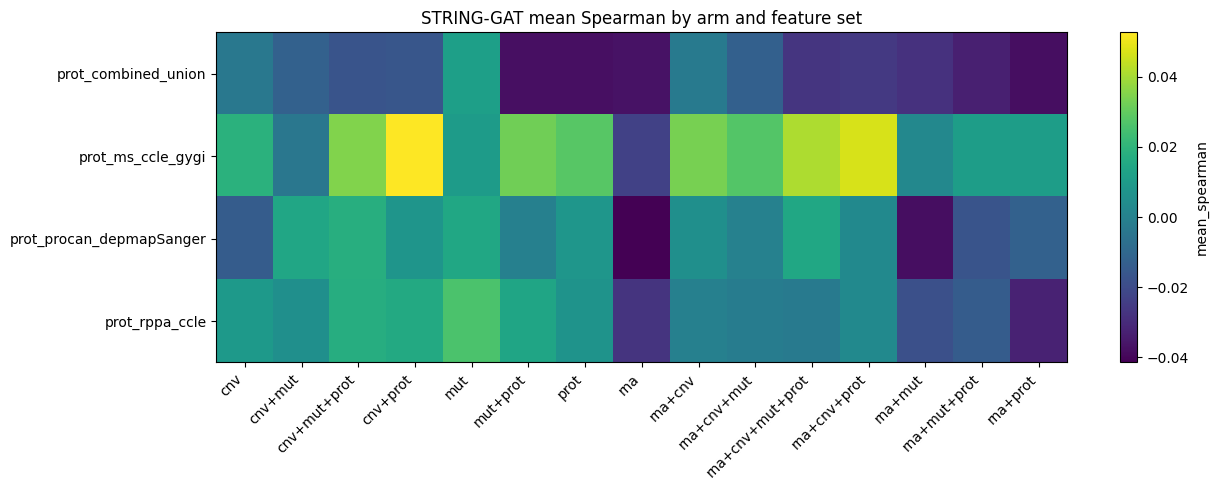

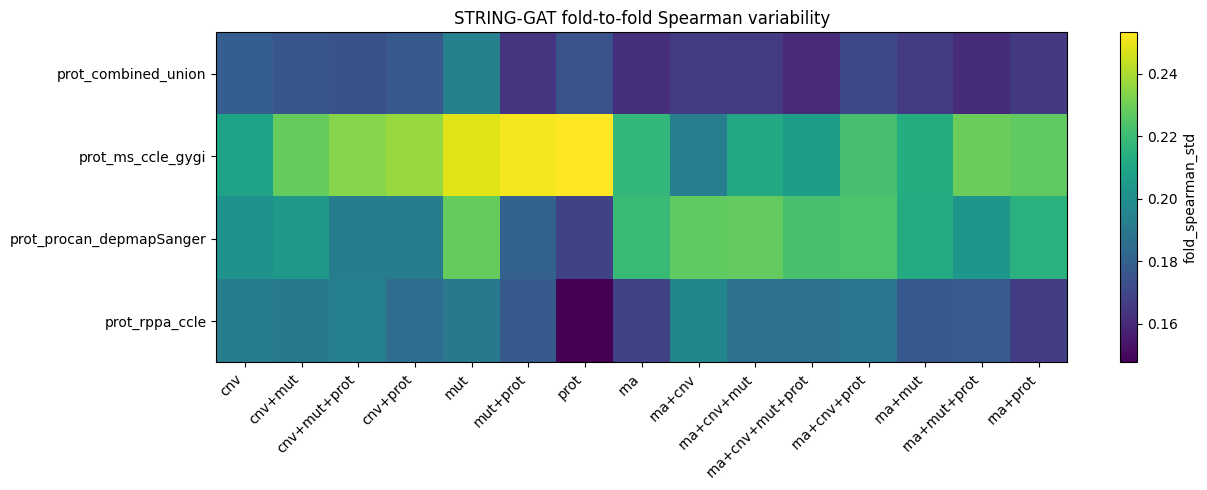

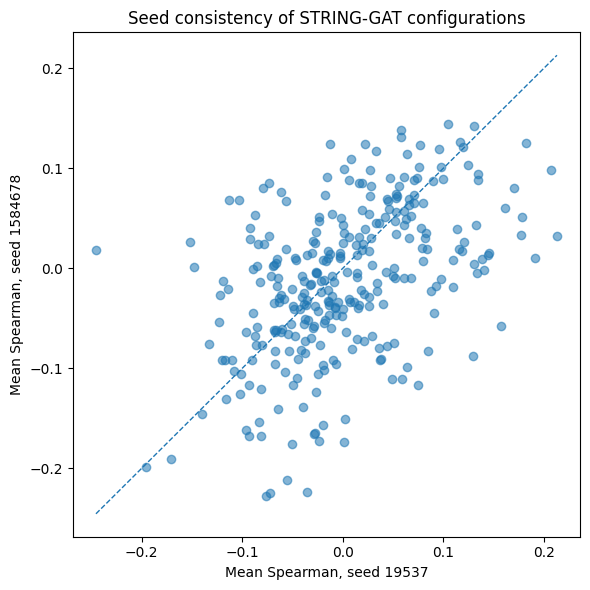

### Most seed-unstable STRING-GAT configurations

seed,arm,feature_set,compound_id,19537,1584678,17052356,abs_seed_delta
173,prot_procan_depmapSanger,mut,PF-05212384 (BRD:BRD-K07955840-001-02-3),-0.245463,0.017913,0.046972,0.263375
130,prot_ms_ccle_gygi,rna+cnv+prot,CR8-(R) (BRD:BRD-K40331046-305-01-5),0.129485,-0.087333,0.029995,0.216819
142,prot_ms_ccle_gygi,rna+mut+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.156939,-0.057420,0.022386,0.214358
112,prot_ms_ccle_gygi,rna,OTS167 (BRD:BRD-K53417444-003-03-1),0.074382,-0.116744,0.023269,0.191126
283,prot_rppa_ccle,rna+cnv+prot,PF-05212384 (BRD:BRD-K07955840-001-02-3),-0.035510,-0.223473,0.068809,0.187962
122,prot_ms_ccle_gygi,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),0.190838,0.009947,0.130905,0.180891
128,prot_ms_ccle_gygi,rna+cnv+mut+prot,PF-05212384 (BRD:BRD-K07955840-001-02-3),-0.112898,0.067859,-0.034200,0.180757
132,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),0.212824,0.032466,0.180355,0.180358
216,prot_procan_depmapSanger,rna+mut+prot,IXAZOMIB (BRD:BRD-K78659596-001-03-9),-0.152257,0.026462,0.020688,0.178719
64,prot_combined_union,rna+mut,SB-2343 (BRD:BRD-K98795921-001-01-7),0.001395,-0.173530,0.002599,0.174925


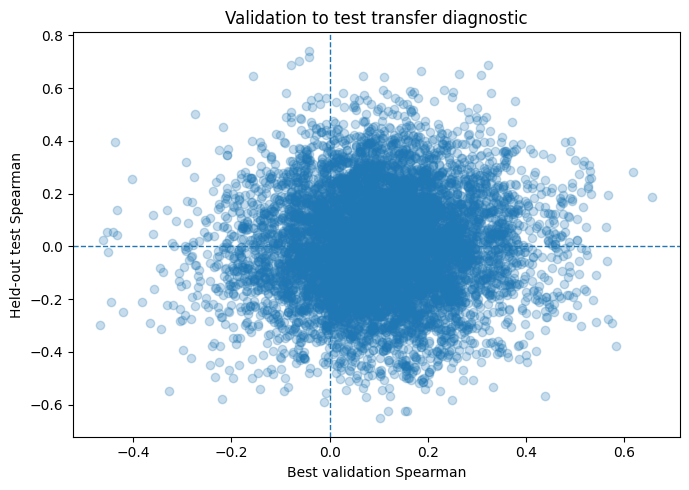

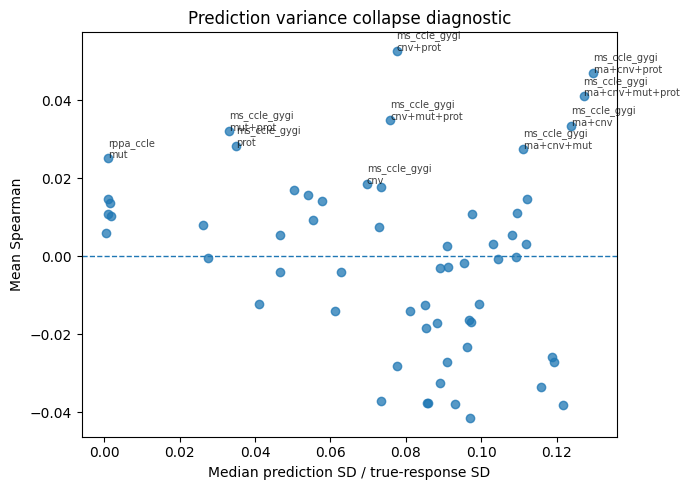

### Configurations with low prediction variance

,arm,feature_set,mean_spearman,median_pred_to_y_std_ratio,median_abs_mean_shift,n_folds
51,prot_rppa_ccle,prot,0.005928,0.000479,0.028174,150
4,prot_combined_union,mut,0.010849,0.000908,0.019537,150
34,prot_procan_depmapSanger,mut,0.014750,0.001024,0.026377,150
49,prot_rppa_ccle,mut,0.025192,0.001069,0.023752,150
50,prot_rppa_ccle,mut+prot,0.013675,0.001474,0.023952,150
19,prot_ms_ccle_gygi,mut,0.010330,0.001726,0.027743,150
36,prot_procan_depmapSanger,prot,0.007940,0.026267,0.028637,150
35,prot_procan_depmapSanger,mut+prot,-0.000454,0.027431,0.029428,150
20,prot_ms_ccle_gygi,mut+prot,0.032241,0.033137,0.029907,150
21,prot_ms_ccle_gygi,prot,0.028303,0.034978,0.033140,150


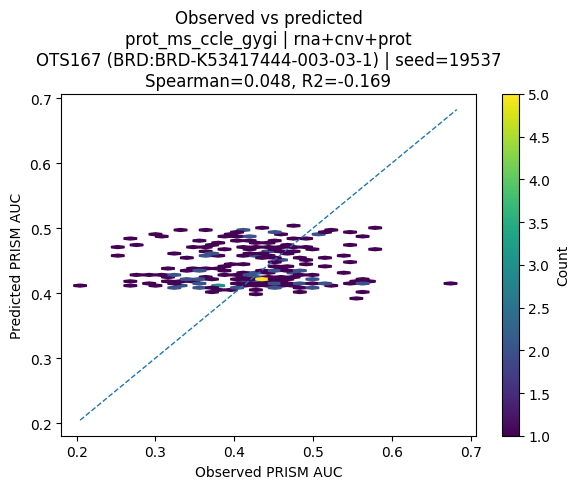

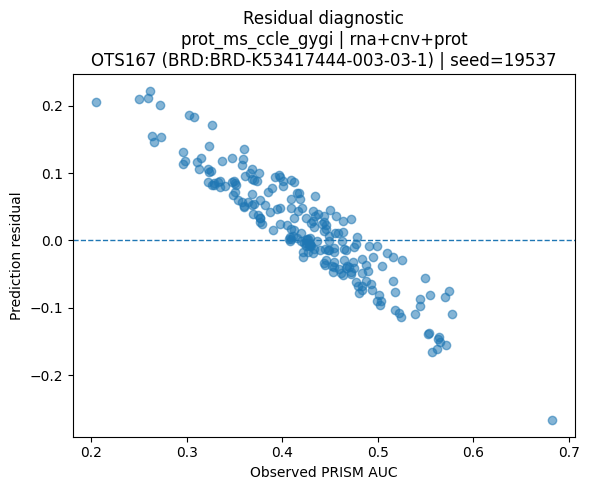

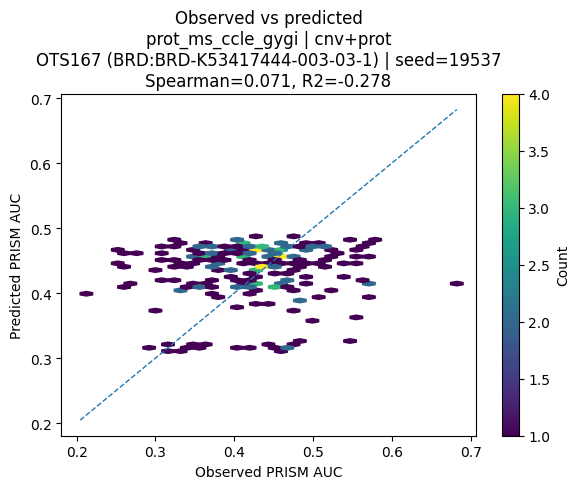

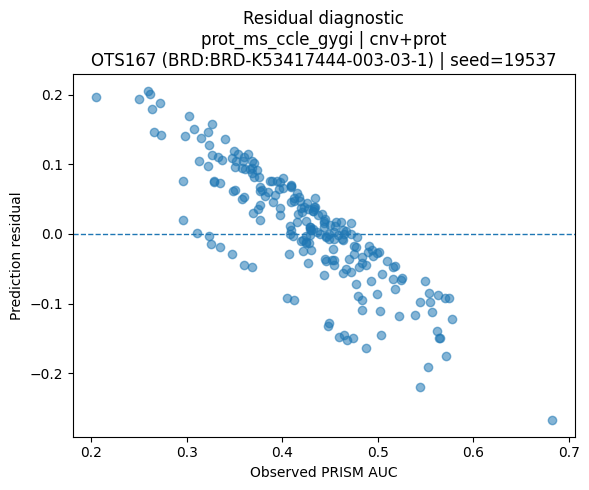

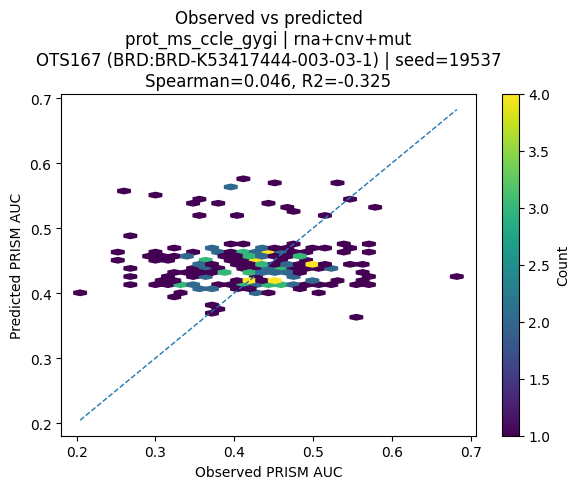

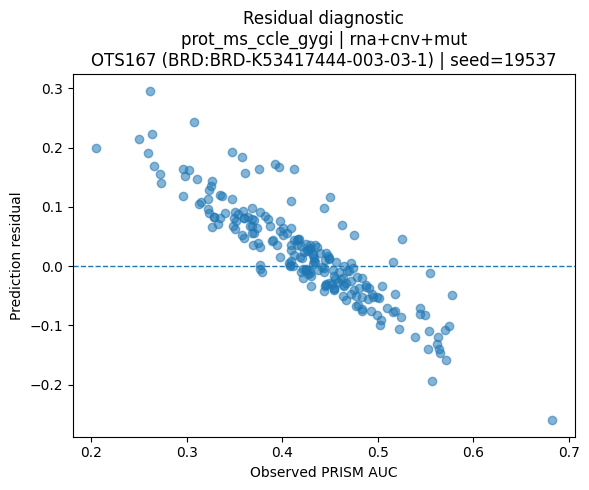

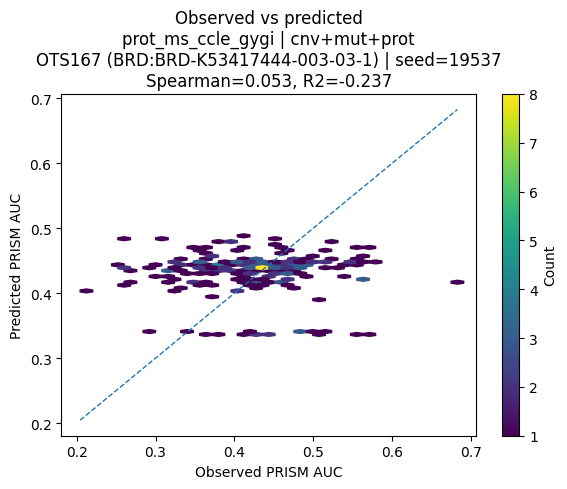

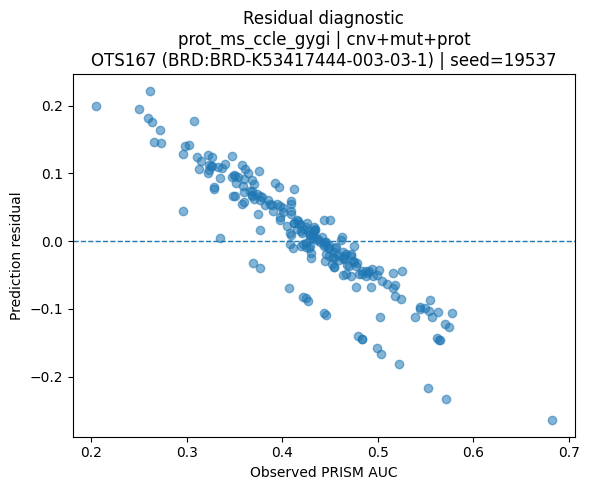

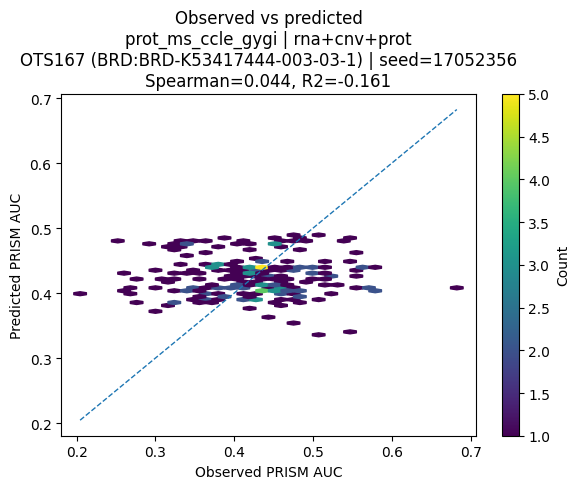

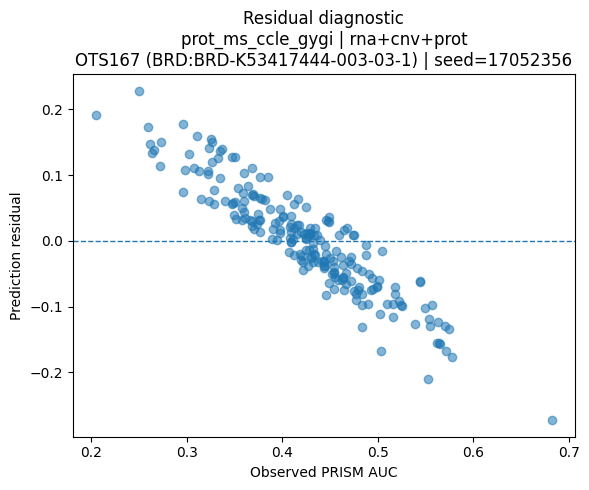

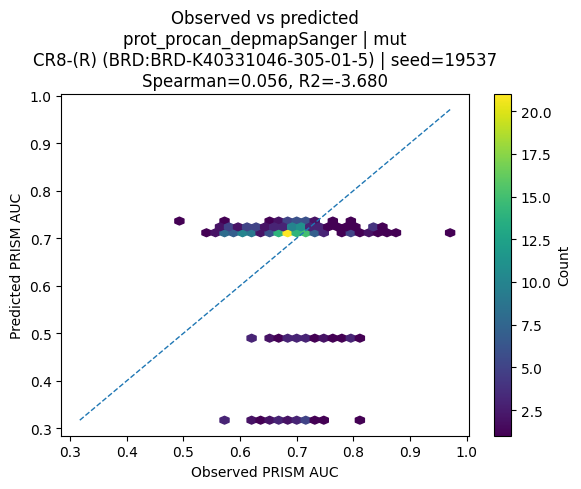

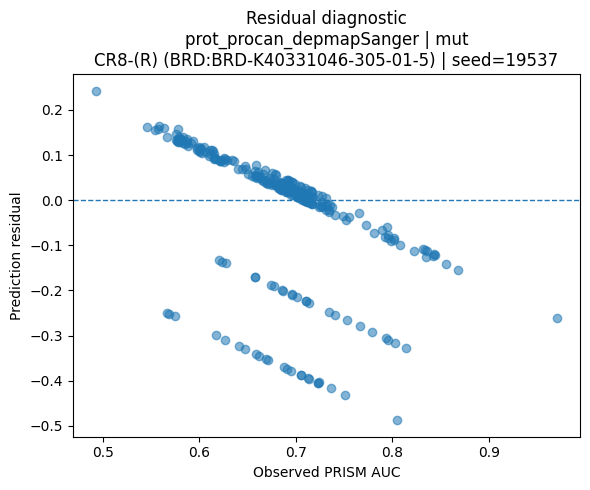

Explaining: 1584678 prot_combined_union mut CR8-(R) (BRD:BRD-K40331046-305-01-5)
Explaining: 19537 prot_ms_ccle_gygi rna+cnv+prot OTS167 (BRD:BRD-K53417444-003-03-1)
Explaining: 19537 prot_procan_depmapSanger mut CR8-(R) (BRD:BRD-K40331046-305-01-5)
Explaining: 17052356 prot_rppa_ccle rna+cnv+mut OTS167 (BRD:BRD-K53417444-003-03-1)


### Advanced explainer index

,seed,arm,feature_set,compound_id,n_explained_samples,ig_node_importance_path,ig_modality_importance_path,ig_channel_importance_path,attention_edges_path,attention_edges_summary_path
0,1584678,prot_combined_union,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),6,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...
1,19537,prot_ms_ccle_gygi,rna+cnv+prot,OTS167 (BRD:BRD-K53417444-003-03-1),6,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...
2,19537,prot_procan_depmapSanger,mut,CR8-(R) (BRD:BRD-K40331046-305-01-5),6,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...
3,17052356,prot_rppa_ccle,rna+cnv+mut,OTS167 (BRD:BRD-K53417444-003-03-1),6,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...,/home/andrija/Desktop/Final Year Project/FYP/a...


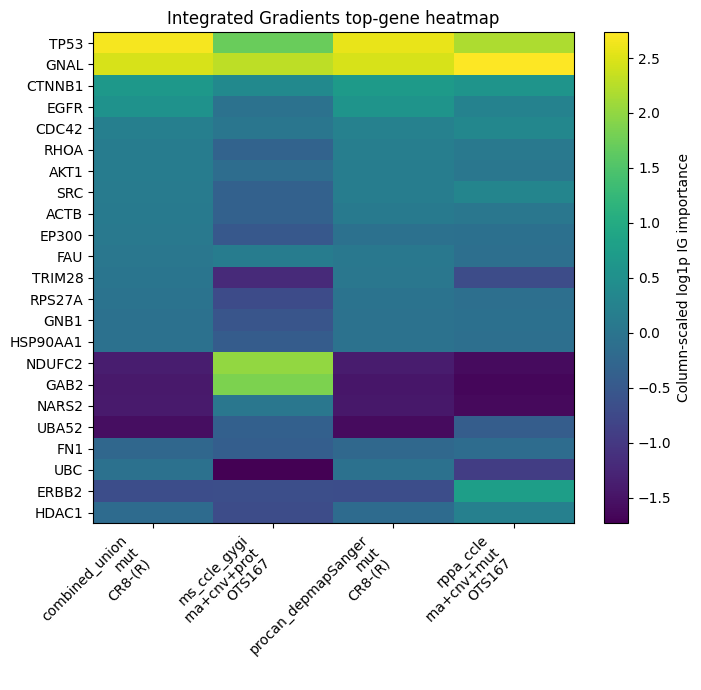

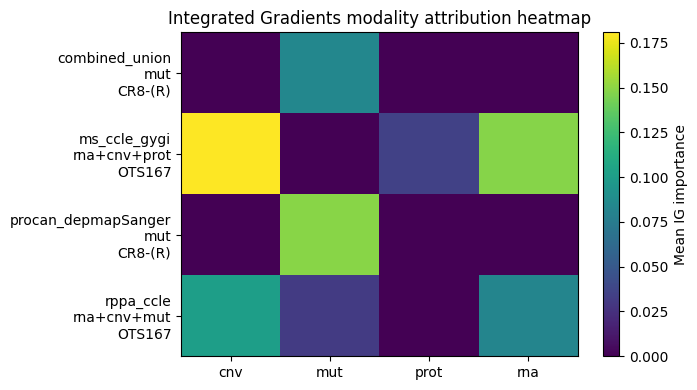

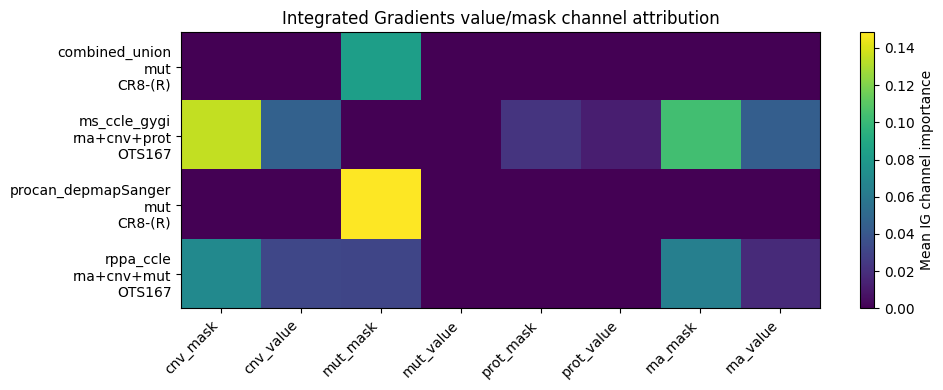

### Integrated Gradients pathway enrichment summary

""


In [ ]:

EDA_DIR = OUT_INTERP / "eda"
EDA_FIG_DIR = OUT_FIGS / "eda"
EDA_TABLE_DIR = EDA_DIR / "tables"
EDA_IG_DIR = EDA_DIR / "integrated_gradients"
EDA_ATTENTION_DIR = EDA_DIR / "attention_edges"
EDA_PATHWAY_DIR = EDA_DIR / "pathway_enrichment"

for p in [
    EDA_DIR,
    EDA_FIG_DIR,
    EDA_TABLE_DIR,
    EDA_IG_DIR,
    EDA_ATTENTION_DIR,
    EDA_PATHWAY_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

ADVANCED_EDA_CONFIG = {
    "n_interpretability_targets_per_arm": 1,
    "n_overall_prediction_targets": 6,
    "max_folds_per_target": 3,
    "max_samples_per_fold": 2,
    "ig_steps": 12,
    "top_genes_for_ora": 200,
    "top_edges_per_sample": 300,
    "top_genes_for_heatmap": 40,
    "top_pathways_for_plot": 12,
}

atomic_write_json(ADVANCED_EDA_CONFIG, EDA_DIR / "advanced_eda_config.json")

CHANNEL_SLICES = {
    "rna": slice(0, 2),
    "cnv": slice(2, 4),
    "mut": slice(4, 6),
    "prot": slice(6, 8),
}

CHANNEL_NAMES = [
    "rna_value", "rna_mask",
    "cnv_value", "cnv_mask",
    "mut_value", "mut_mask",
    "prot_value", "prot_mask",
]

def _wrap_label(x: str, width: int = 42) -> str:
    return "\n".join(textwrap.wrap(str(x), width=width))

def _safe_float(x, default=np.nan) -> float:
    try:
        out = float(x)
        return out if np.isfinite(out) else default
    except Exception:
        return default

def _read_prediction_file(path) -> pd.DataFrame:
    if pd.isna(path):
        return pd.DataFrame()
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
    except Exception:
        return pd.DataFrame()
    needed = {"y_true", "y_pred"}
    if df.empty or not needed.issubset(df.columns):
        return pd.DataFrame()
    df["y_true"] = pd.to_numeric(df["y_true"], errors="coerce")
    df["y_pred"] = pd.to_numeric(df["y_pred"], errors="coerce")
    return df.dropna(subset=["y_true", "y_pred"]).copy()

def _config_label(row) -> str:
    return f"{row['arm']} | {row['feature_set']} | {row['compound_id']} | seed={row['seed']}"

def _select_interpretability_targets(per_drug_seed: pd.DataFrame) -> pd.DataFrame:
    df = per_drug_seed.copy()
    df["mean_spearman"] = pd.to_numeric(df["mean_spearman"], errors="coerce")
    df["median_spearman"] = pd.to_numeric(df["median_spearman"], errors="coerce")
    df = df.dropna(subset=["mean_spearman"])

    picked = []
    for arm_name, sub in df.groupby("arm"):
        sub = sub.sort_values(["mean_spearman", "median_spearman"], ascending=False)
        picked.append(sub.head(ADVANCED_EDA_CONFIG["n_interpretability_targets_per_arm"]))

    if not picked:
        return pd.DataFrame()

    out = pd.concat(picked, ignore_index=True)
    out = out.drop_duplicates(subset=["seed", "arm", "feature_set", "compound_id"])
    return out.reset_index(drop=True)

def _select_prediction_targets(per_drug_seed: pd.DataFrame) -> pd.DataFrame:
    df = per_drug_seed.copy()
    df["mean_spearman"] = pd.to_numeric(df["mean_spearman"], errors="coerce")
    df = df.dropna(subset=["mean_spearman"])
    return (
        df.sort_values(["mean_spearman", "median_spearman"], ascending=False)
        .head(ADVANCED_EDA_CONFIG["n_overall_prediction_targets"])
        .reset_index(drop=True)
    )

advanced_interp_targets = _select_interpretability_targets(per_drug_seed)
advanced_prediction_targets = _select_prediction_targets(per_drug_seed)

advanced_interp_targets.to_csv(EDA_TABLE_DIR / "advanced_interpretability_targets.csv", index=False)
advanced_prediction_targets.to_csv(EDA_TABLE_DIR / "advanced_prediction_targets.csv", index=False)

display(Markdown("### Selected configurations for additional interpretation"))
display(advanced_interp_targets)

display(Markdown("### Selected configurations for prediction diagnostics"))
display(advanced_prediction_targets)

def plot_heatmap_matrix(
    df: pd.DataFrame,
    value_col: str,
    index_col: str,
    column_col: str,
    title: str,
    out_path: Path,
    figsize=(11, 5),
):
    if df.empty or value_col not in df.columns:
        return

    tmp = df.copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    pivot = tmp.pivot_table(index=index_col, columns=column_col, values=value_col, aggfunc="mean")
    if pivot.empty:
        return

    plt.figure(figsize=figsize)
    im = plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, label=value_col)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()

plot_heatmap_matrix(
    arm_feature_summary,
    value_col="mean_spearman",
    index_col="arm",
    column_col="feature_set",
    title="STRING-GAT mean Spearman by arm and feature set",
    out_path=EDA_FIG_DIR / "heatmap_mean_spearman_arm_feature.png",
    figsize=(13, 5),
)

fold_variability = (
    per_fold_df.groupby(["arm", "feature_set"], as_index=False)
    .agg(
        fold_spearman_std=("spearman", "std"),
        fold_spearman_iqr=("spearman", lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25)),
        mean_spearman=("spearman", "mean"),
        n_rows=("spearman", "count"),
    )
)
fold_variability.to_csv(EDA_TABLE_DIR / "fold_variability_by_arm_feature.csv", index=False)

plot_heatmap_matrix(
    fold_variability,
    value_col="fold_spearman_std",
    index_col="arm",
    column_col="feature_set",
    title="STRING-GAT fold-to-fold Spearman variability",
    out_path=EDA_FIG_DIR / "heatmap_fold_spearman_std_arm_feature.png",
    figsize=(13, 5),
)

if set(SEEDS).issubset(set(per_drug_seed["seed"].unique())) and len(SEEDS) >= 2:
    seed_pivot = per_drug_seed.pivot_table(
        index=["arm", "feature_set", "compound_id"],
        columns="seed",
        values="mean_spearman",
        aggfunc="mean",
    )
    seed_pivot = seed_pivot.dropna(subset=SEEDS[:2]).copy()
    if not seed_pivot.empty:
        seed_pivot["abs_seed_delta"] = (seed_pivot[SEEDS[0]] - seed_pivot[SEEDS[1]]).abs()
        seed_pivot = seed_pivot.reset_index()
        seed_pivot.to_csv(EDA_TABLE_DIR / "seed_consistency_per_config.csv", index=False)

        plt.figure(figsize=(6, 6))
        plt.scatter(seed_pivot[SEEDS[0]], seed_pivot[SEEDS[1]], alpha=0.55)
        lo = np.nanmin(seed_pivot[[SEEDS[0], SEEDS[1]]].to_numpy())
        hi = np.nanmax(seed_pivot[[SEEDS[0], SEEDS[1]]].to_numpy())
        plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
        plt.xlabel(f"Mean Spearman, seed {SEEDS[0]}")
        plt.ylabel(f"Mean Spearman, seed {SEEDS[1]}")
        plt.title("Seed consistency of STRING-GAT configurations")
        plt.tight_layout()
        plt.savefig(EDA_FIG_DIR / "seed_consistency_scatter.png", dpi=180, bbox_inches="tight")
        plt.show()

        display(Markdown("### Most seed-unstable STRING-GAT configurations"))
        display(seed_pivot.sort_values("abs_seed_delta", ascending=False).head(15))

if {"best_val_spearman", "spearman"}.issubset(per_fold_df.columns):
    diag_df = per_fold_df.copy()
    diag_df["best_val_spearman"] = pd.to_numeric(diag_df["best_val_spearman"], errors="coerce")
    diag_df["spearman"] = pd.to_numeric(diag_df["spearman"], errors="coerce")
    diag_df = diag_df.dropna(subset=["best_val_spearman", "spearman"])

    if not diag_df.empty:
        plt.figure(figsize=(7, 5))
        plt.scatter(diag_df["best_val_spearman"], diag_df["spearman"], alpha=0.25)
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.xlabel("Best validation Spearman")
        plt.ylabel("Held-out test Spearman")
        plt.title("Validation to test transfer diagnostic")
        plt.tight_layout()
        plt.savefig(EDA_FIG_DIR / "validation_vs_test_spearman_scatter.png", dpi=180, bbox_inches="tight")
        plt.show()

prediction_variance_rows = []

for _, row in per_fold_df.iterrows():
    pred_df = _read_prediction_file(row.get("predictions_path", None))
    if pred_df.empty:
        continue

    y_true = pred_df["y_true"].to_numpy(dtype=float)
    y_pred = pred_df["y_pred"].to_numpy(dtype=float)
    y_std = float(np.nanstd(y_true))
    pred_std = float(np.nanstd(y_pred))

    prediction_variance_rows.append({
        "seed": row["seed"],
        "arm": row["arm"],
        "feature_set": row["feature_set"],
        "compound_id": row["compound_id"],
        "fold_idx": row["fold_idx"],
        "spearman": row["spearman"],
        "r2": row["r2"],
        "y_mean": float(np.nanmean(y_true)),
        "y_std": y_std,
        "pred_mean": float(np.nanmean(y_pred)),
        "pred_std": pred_std,
        "pred_to_y_std_ratio": pred_std / y_std if y_std > 1e-12 else np.nan,
        "abs_mean_shift": abs(float(np.nanmean(y_pred)) - float(np.nanmean(y_true))),
        "predictions_path": row.get("predictions_path", None),
    })

prediction_variance_df = pd.DataFrame(prediction_variance_rows)
prediction_variance_df.to_csv(EDA_TABLE_DIR / "prediction_variance_per_fold.csv", index=False)

if not prediction_variance_df.empty:
    prediction_variance_summary = (
        prediction_variance_df.groupby(["arm", "feature_set"], as_index=False)
        .agg(
            mean_spearman=("spearman", "mean"),
            median_pred_to_y_std_ratio=("pred_to_y_std_ratio", "median"),
            median_abs_mean_shift=("abs_mean_shift", "median"),
            n_folds=("fold_idx", "count"),
        )
        .sort_values("mean_spearman", ascending=False)
    )
    prediction_variance_summary.to_csv(EDA_TABLE_DIR / "prediction_variance_summary_by_arm_feature.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        prediction_variance_summary["median_pred_to_y_std_ratio"],
        prediction_variance_summary["mean_spearman"],
        alpha=0.75,
    )
    for _, r in prediction_variance_summary.head(10).iterrows():
        label = f"{r['arm'].replace('prot_', '')}\n{r['feature_set']}"
        plt.annotate(label, (r["median_pred_to_y_std_ratio"], r["mean_spearman"]), fontsize=7, alpha=0.75)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Median prediction SD / true-response SD")
    plt.ylabel("Mean Spearman")
    plt.title("Prediction variance collapse diagnostic")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / "prediction_variance_vs_spearman_scatter.png", dpi=180, bbox_inches="tight")
    plt.show()

    display(Markdown("### Configurations with low prediction variance"))
    display(
        prediction_variance_summary
        .sort_values(["median_pred_to_y_std_ratio", "mean_spearman"], ascending=[True, True])
        .head(20)
    )

def plot_prediction_diagnostics_for_target(target_row: pd.Series):
    match = (
        (per_fold_df["seed"] == int(target_row["seed"])) &
        (per_fold_df["arm"] == target_row["arm"]) &
        (per_fold_df["feature_set"] == target_row["feature_set"]) &
        (per_fold_df["compound_id"] == target_row["compound_id"])
    )
    rows = per_fold_df[match].copy()
    if rows.empty:
        return

    pred_frames = []
    for _, r in rows.iterrows():
        pred_df = _read_prediction_file(r.get("predictions_path", None))
        if pred_df.empty:
            continue
        pred_df["fold_idx"] = r["fold_idx"]
        pred_frames.append(pred_df)

    if not pred_frames:
        return

    df = pd.concat(pred_frames, ignore_index=True).dropna(subset=["y_true", "y_pred"])
    if df.empty:
        return

    spearman = spearman_safe(df["y_true"], df["y_pred"])
    r2 = r2_safe(df["y_true"], df["y_pred"])

    title_stub = (
        f"{target_row['arm']} | {target_row['feature_set']}\n"
        f"{target_row['compound_id']} | seed={target_row['seed']}"
    )
    file_stub = "__".join([
        safe_slug(str(target_row["seed"])),
        safe_slug(target_row["arm"]),
        safe_slug(target_row["feature_set"].replace("+", "_")),
        safe_slug(target_row["compound_id"]),
    ])

    plt.figure(figsize=(6, 5))
    if df.shape[0] >= 40:
        plt.hexbin(df["y_true"], df["y_pred"], gridsize=30, mincnt=1)
        plt.colorbar(label="Count")
    else:
        plt.scatter(df["y_true"], df["y_pred"], alpha=0.75)

    lo = np.nanmin(df[["y_true", "y_pred"]].to_numpy())
    hi = np.nanmax(df[["y_true", "y_pred"]].to_numpy())
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    plt.xlabel("Observed PRISM AUC")
    plt.ylabel("Predicted PRISM AUC")
    plt.title(f"Observed vs predicted\n{title_stub}\nSpearman={spearman:.3f}, R2={r2:.3f}")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / f"prediction_hexbin__{file_stub}.png", dpi=180, bbox_inches="tight")
    plt.show()

    df["residual"] = df["y_pred"] - df["y_true"]

    plt.figure(figsize=(6, 5))
    plt.scatter(df["y_true"], df["residual"], alpha=0.55)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Observed PRISM AUC")
    plt.ylabel("Prediction residual")
    plt.title(f"Residual diagnostic\n{title_stub}")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / f"residual_scatter__{file_stub}.png", dpi=180, bbox_inches="tight")
    plt.show()

for _, target_row in advanced_prediction_targets.iterrows():
    plot_prediction_diagnostics_for_target(target_row)


def make_single_sample_data(x_np: np.ndarray, y_value: float) -> Data:
    data = Data(
        x=torch.from_numpy(x_np.astype(np.float32, copy=False)),
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([float(y_value)], dtype=torch.float32),
    )
    data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
    return data

def integrated_gradients_node_feature(
    model: nn.Module,
    data: Data,
    steps: int = 12,
    baseline: Optional[torch.Tensor] = None,
) -> Tuple[np.ndarray, Dict[str, float], Dict[str, float]]:
    model.eval()
    data = copy.deepcopy(data).to(DEVICE)

    x = data.x.detach()
    if baseline is None:
        baseline = torch.zeros_like(x)
    else:
        baseline = baseline.to(DEVICE).detach()

    total_grad = torch.zeros_like(x)

    # Avoid exactly zero only path. This keeps the baseline included while still
    # giving a stable gradient average.
    alphas = torch.linspace(0.0, 1.0, steps, device=DEVICE)

    for alpha in alphas:
        scaled_x = (baseline + alpha * (x - baseline)).detach().requires_grad_(True)

        data_step = Data(
            x=scaled_x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
        )
        data_step.batch = data.batch

        model.zero_grad(set_to_none=True)
        pred = model(data_step).sum()
        pred.backward()

        if scaled_x.grad is not None:
            total_grad += scaled_x.grad.detach()

    avg_grad = total_grad / max(int(steps), 1)
    attr = ((x - baseline) * avg_grad).detach().cpu().numpy()
    attr_abs = np.abs(attr)

    gene_importance = attr_abs.sum(axis=1)

    modality_importance = {}
    for modality, sl in CHANNEL_SLICES.items():
        modality_importance[modality] = float(attr_abs[:, sl].sum())

    channel_importance = {
        CHANNEL_NAMES[i]: float(attr_abs[:, i].sum())
        for i in range(attr_abs.shape[1])
    }

    return gene_importance, modality_importance, channel_importance

@torch.no_grad()
def extract_gat_attention_edges(
    model: nn.Module,
    data: Data,
    top_k: int = 300,
) -> pd.DataFrame:
    model.eval()
    data = copy.deepcopy(data).to(DEVICE)

    edge_attr_use = data.edge_attr if hasattr(data, "edge_attr") else None

    h1, attn_info_1 = model.conv1(
        data.x,
        data.edge_index,
        edge_attr=edge_attr_use,
        return_attention_weights=True,
    )
    edge_idx_1, alpha_1 = attn_info_1
    h1 = model.norm1(h1)
    h1 = F.elu(h1)

    h2, attn_info_2 = model.conv2(
        h1,
        data.edge_index,
        edge_attr=edge_attr_use,
        return_attention_weights=True,
    )
    edge_idx_2, alpha_2 = attn_info_2

    rows = []

    def collect_layer(layer_name: str, edge_idx: torch.Tensor, alpha: torch.Tensor):
        if alpha.ndim == 2:
            score = alpha.mean(dim=1)
        else:
            score = alpha.reshape(-1)

        edge_idx_cpu = edge_idx.detach().cpu().numpy()
        score_cpu = score.detach().cpu().numpy()

        finite = np.isfinite(score_cpu)
        if finite.sum() == 0:
            return

        valid_idx = np.where(finite)[0]
        valid_scores = score_cpu[valid_idx]
        order = valid_idx[np.argsort(valid_scores)[::-1][:top_k]]

        for edge_rank, eidx in enumerate(order, start=1):
            src_idx = int(edge_idx_cpu[0, eidx])
            dst_idx = int(edge_idx_cpu[1, eidx])

            if src_idx < 0 or dst_idx < 0:
                continue
            if src_idx >= len(graph_nodes) or dst_idx >= len(graph_nodes):
                continue
            if src_idx == dst_idx:
                continue

            rows.append({
                "layer": layer_name,
                "edge_rank": edge_rank,
                "source_gene": graph_nodes[src_idx],
                "target_gene": graph_nodes[dst_idx],
                "source_idx": src_idx,
                "target_idx": dst_idx,
                "attention_mean_over_heads": float(score_cpu[eidx]),
            })

    collect_layer("conv1", edge_idx_1, alpha_1)
    collect_layer("conv2", edge_idx_2, alpha_2)

    return pd.DataFrame(rows)

def explain_target_with_ig_and_attention(target_row: pd.Series) -> Optional[dict]:
    arm_name = target_row["arm"]
    feature_set = target_row["feature_set"]
    compound_id = target_row["compound_id"]
    seed = int(target_row["seed"])

    eligible_cells = get_arm_cohort(arm_name)
    y_series = get_drug_target_series(compound_id, eligible_cells)
    sample_ids = y_series.index.tolist()

    if len(sample_ids) < MIN_CELLS_PER_DRUG:
        return None

    sample_groups = cell_index.loc[sample_ids, group_col].astype(str)
    outer_folds, _, _ = get_outer_folds_cached(sample_ids, sample_groups, seed, arm_name, compound_id)

    ig_gene_scores = []
    gx_gene_scores = []
    modality_rows = []
    channel_rows = []
    attention_rows = []

    completed_folds = 0

    for fold_idx, (train_ids, test_ids) in enumerate(outer_folds):
        if completed_folds >= ADVANCED_EDA_CONFIG["max_folds_per_target"]:
            break

        key_match = (
            (per_fold_df["seed"] == seed) &
            (per_fold_df["arm"] == arm_name) &
            (per_fold_df["feature_set"] == feature_set) &
            (per_fold_df["compound_id"] == compound_id) &
            (per_fold_df["fold_idx"] == fold_idx)
        )
        if key_match.sum() == 0:
            continue

        model_row = per_fold_df[key_match].iloc[0]
        model_path = model_row.get("model_path", None)
        if pd.isna(model_path) or not Path(model_path).exists():
            continue

        fold_tensor_payload_base = {
            "seed": seed,
            "arm": arm_name,
            "drug": compound_id,
            "fold_idx": fold_idx,
            "train_ids": train_ids,
            "test_ids": test_ids,
            "cache_version": CACHE_VERSION,
        }
        cache_key_base = stable_hash(fold_tensor_payload_base, n=24)

        all_ids = train_ids + test_ids
        x_base = build_fold_tensor_base(
            arm_name=arm_name,
            all_ids=all_ids,
            train_ids=train_ids,
            cache_key=cache_key_base,
        )
        x_all = apply_feature_set_mask(x_base, feature_set)
        id_to_pos = {cid: i for i, cid in enumerate(all_ids)}

        model = load_saved_model_for_row(model_row)

        selected_test_ids = list(test_ids[:ADVANCED_EDA_CONFIG["max_samples_per_fold"]])

        for sample_rank, cid in enumerate(selected_test_ids, start=1):
            if cid not in id_to_pos or cid not in y_series.index:
                continue

            pos = id_to_pos[cid]
            data = make_single_sample_data(x_all[pos], float(y_series.loc[cid]))

            gx_gene_imp, gx_modality_imp = gradient_x_input_importance(model, data)
            ig_gene_imp, ig_modality_imp, ig_channel_imp = integrated_gradients_node_feature(
                model,
                data,
                steps=ADVANCED_EDA_CONFIG["ig_steps"],
            )

            ig_gene_scores.append(ig_gene_imp)
            gx_gene_scores.append(gx_gene_imp)

            modality_row = {
                "seed": seed,
                "arm": arm_name,
                "feature_set": feature_set,
                "compound_id": compound_id,
                "fold_idx": fold_idx,
                "depmap_id": cid,
                "sample_rank_in_fold": sample_rank,
            }
            for modality in ["rna", "cnv", "mut", "prot"]:
                modality_row[f"ig_{modality}"] = ig_modality_imp.get(modality, np.nan)
                modality_row[f"gradxinput_{modality}"] = gx_modality_imp.get(modality, np.nan)
            modality_rows.append(modality_row)

            channel_row = {
                "seed": seed,
                "arm": arm_name,
                "feature_set": feature_set,
                "compound_id": compound_id,
                "fold_idx": fold_idx,
                "depmap_id": cid,
                "sample_rank_in_fold": sample_rank,
            }
            channel_row.update(ig_channel_imp)
            channel_rows.append(channel_row)

            attn_df = extract_gat_attention_edges(
                model,
                data,
                top_k=ADVANCED_EDA_CONFIG["top_edges_per_sample"],
            )
            if not attn_df.empty:
                attn_df["seed"] = seed
                attn_df["arm"] = arm_name
                attn_df["feature_set"] = feature_set
                attn_df["compound_id"] = compound_id
                attn_df["fold_idx"] = fold_idx
                attn_df["depmap_id"] = cid
                attention_rows.append(attn_df)

        completed_folds += 1

        del model, x_all, x_base
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not ig_gene_scores:
        return None

    ig_mean = np.mean(np.vstack(ig_gene_scores), axis=0)
    gx_mean = np.mean(np.vstack(gx_gene_scores), axis=0) if gx_gene_scores else np.zeros_like(ig_mean)

    node_rank_df = pd.DataFrame({
        "gene_symbol": graph_nodes,
        "ig_importance": ig_mean,
        "gradxinput_importance": gx_mean,
        "in_string_high_confidence_component": [
            bool(g in genes_in_component) for g in graph_nodes
        ],
    }).sort_values("ig_importance", ascending=False).reset_index(drop=True)

    file_stub = "__".join([
        f"seed{seed}",
        safe_slug(arm_name),
        safe_slug(feature_set.replace("+", "_")),
        safe_slug(compound_id),
    ])

    node_path = EDA_IG_DIR / f"ig_node_importance__{file_stub}.csv"
    node_rank_df.to_csv(node_path, index=False)

    modality_df = pd.DataFrame(modality_rows)
    modality_path = EDA_IG_DIR / f"ig_modality_importance__{file_stub}.csv"
    modality_df.to_csv(modality_path, index=False)

    channel_df = pd.DataFrame(channel_rows)
    channel_path = EDA_IG_DIR / f"ig_channel_importance__{file_stub}.csv"
    channel_df.to_csv(channel_path, index=False)

    if attention_rows:
        attention_df = pd.concat(attention_rows, ignore_index=True)
    else:
        attention_df = pd.DataFrame(columns=[
            "layer", "edge_rank", "source_gene", "target_gene",
            "attention_mean_over_heads",
        ])

    attention_path = EDA_ATTENTION_DIR / f"attention_edges__{file_stub}.csv"
    attention_df.to_csv(attention_path, index=False)

    if not attention_df.empty:
        attention_summary = (
            attention_df.groupby(["layer", "source_gene", "target_gene"], as_index=False)
            .agg(
                mean_attention=("attention_mean_over_heads", "mean"),
                max_attention=("attention_mean_over_heads", "max"),
                n_samples=("depmap_id", "nunique"),
                n_occurrences=("attention_mean_over_heads", "count"),
            )
            .sort_values(["layer", "mean_attention"], ascending=[True, False])
        )
    else:
        attention_summary = pd.DataFrame(columns=[
            "layer",
            "source_gene",
            "target_gene",
            "mean_attention",
            "max_attention",
            "n_samples",
            "n_occurrences",
        ])

    attention_summary_path = EDA_ATTENTION_DIR / f"attention_edges_summary__{file_stub}.csv"
    attention_summary.to_csv(attention_summary_path, index=False)

    return {
        "seed": seed,
        "arm": arm_name,
        "feature_set": feature_set,
        "compound_id": compound_id,
        "n_explained_samples": int(len(ig_gene_scores)),
        "ig_node_importance_path": str(node_path),
        "ig_modality_importance_path": str(modality_path),
        "ig_channel_importance_path": str(channel_path),
        "attention_edges_path": str(attention_path),
        "attention_edges_summary_path": str(attention_summary_path),
    }

advanced_explainer_rows = []

for _, target_row in advanced_interp_targets.iterrows():
    print(
        "Explaining:",
        target_row["seed"],
        target_row["arm"],
        target_row["feature_set"],
        target_row["compound_id"],
        flush=True,
    )
    out = explain_target_with_ig_and_attention(target_row)
    if out is not None:
        advanced_explainer_rows.append(out)

advanced_explainer_index = pd.DataFrame(advanced_explainer_rows)
advanced_explainer_index.to_csv(EDA_DIR / "advanced_explainer_index.csv", index=False)

display(Markdown("### Advanced explainer index"))
display(advanced_explainer_index)


def plot_ig_gene_heatmap(explainer_index: pd.DataFrame):
    if explainer_index.empty:
        return

    loaded = []
    for _, row in explainer_index.iterrows():
        path = Path(row["ig_node_importance_path"])
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if df.empty or "gene_symbol" not in df.columns or "ig_importance" not in df.columns:
            continue
        label = f"{row['arm'].replace('prot_', '')}\n{row['feature_set']}\n{str(row['compound_id']).split(' ')[0]}"
        tmp = df[["gene_symbol", "ig_importance"]].copy()
        tmp = tmp.rename(columns={"ig_importance": label})
        loaded.append(tmp)

    if not loaded:
        return

    top_genes = []
    for df in loaded:
        score_col = [c for c in df.columns if c != "gene_symbol"][0]
        top_genes.extend(df.sort_values(score_col, ascending=False).head(15)["gene_symbol"].astype(str).tolist())

    top_genes = list(dict.fromkeys(top_genes))[:ADVANCED_EDA_CONFIG["top_genes_for_heatmap"]]

    merged = pd.DataFrame({"gene_symbol": top_genes})
    for df in loaded:
        merged = merged.merge(df, on="gene_symbol", how="left")

    merged = merged.fillna(0.0)
    value_cols = [c for c in merged.columns if c != "gene_symbol"]
    mat = merged[value_cols].to_numpy(dtype=float)
    mat = np.log1p(mat)
    mat = (mat - mat.mean(axis=0, keepdims=True)) / (mat.std(axis=0, keepdims=True) + 1e-8)

    heatmap_df = pd.DataFrame(mat, index=merged["gene_symbol"], columns=value_cols)
    heatmap_df.to_csv(EDA_TABLE_DIR / "ig_top_gene_heatmap_matrix.csv")

    plt.figure(figsize=(max(7, 1.8 * len(value_cols)), max(7, 0.22 * len(top_genes))))
    im = plt.imshow(mat, aspect="auto")
    plt.colorbar(im, label="Column-scaled log1p IG importance")
    plt.xticks(np.arange(len(value_cols)), value_cols, rotation=45, ha="right")
    plt.yticks(np.arange(len(top_genes)), top_genes)
    plt.title("Integrated Gradients top-gene heatmap")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / "ig_top_gene_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

plot_ig_gene_heatmap(advanced_explainer_index)

ig_modality_frames = []
ig_channel_frames = []

for _, row in advanced_explainer_index.iterrows():
    mod_path = Path(row["ig_modality_importance_path"])
    ch_path = Path(row["ig_channel_importance_path"])

    if mod_path.exists():
        df = pd.read_csv(mod_path)
        if not df.empty:
            ig_modality_frames.append(df)

    if ch_path.exists():
        df = pd.read_csv(ch_path)
        if not df.empty:
            ig_channel_frames.append(df)

if ig_modality_frames:
    ig_modality_all = pd.concat(ig_modality_frames, ignore_index=True)
else:
    ig_modality_all = pd.DataFrame()

if ig_channel_frames:
    ig_channel_all = pd.concat(ig_channel_frames, ignore_index=True)
else:
    ig_channel_all = pd.DataFrame()

ig_modality_all.to_csv(EDA_TABLE_DIR / "ig_modality_importance_all_samples.csv", index=False)
ig_channel_all.to_csv(EDA_TABLE_DIR / "ig_channel_importance_all_samples.csv", index=False)

if not ig_modality_all.empty:
    value_cols = [c for c in ig_modality_all.columns if c.startswith("ig_") or c.startswith("gradxinput_")]
    modality_summary = (
        ig_modality_all.groupby(["arm", "feature_set", "compound_id"], as_index=False)[value_cols]
        .mean()
    )
    modality_summary.to_csv(EDA_TABLE_DIR / "ig_modality_importance_summary.csv", index=False)

    long_rows = []
    for _, r in modality_summary.iterrows():
        for modality in ["rna", "cnv", "mut", "prot"]:
            long_rows.append({
                "config": f"{r['arm'].replace('prot_', '')}\n{r['feature_set']}\n{str(r['compound_id']).split(' ')[0]}",
                "modality": modality,
                "ig_importance": r.get(f"ig_{modality}", np.nan),
                "gradxinput_importance": r.get(f"gradxinput_{modality}", np.nan),
            })
    modality_long = pd.DataFrame(long_rows)
    modality_pivot = modality_long.pivot_table(index="config", columns="modality", values="ig_importance", aggfunc="mean").fillna(0.0)

    plt.figure(figsize=(7, max(4, 0.6 * len(modality_pivot))))
    im = plt.imshow(modality_pivot.values, aspect="auto")
    plt.colorbar(im, label="Mean IG importance")
    plt.xticks(np.arange(len(modality_pivot.columns)), modality_pivot.columns)
    plt.yticks(np.arange(len(modality_pivot.index)), modality_pivot.index)
    plt.title("Integrated Gradients modality attribution heatmap")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / "ig_modality_attribution_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

if not ig_channel_all.empty:
    meta_cols = ["seed", "arm", "feature_set", "compound_id", "fold_idx", "depmap_id", "sample_rank_in_fold"]
    channel_cols = [c for c in ig_channel_all.columns if c not in meta_cols]
    channel_summary = (
        ig_channel_all.groupby(["arm", "feature_set", "compound_id"], as_index=False)[channel_cols]
        .mean()
    )
    channel_summary.to_csv(EDA_TABLE_DIR / "ig_channel_importance_summary.csv", index=False)

    melted = channel_summary.melt(
        id_vars=["arm", "feature_set", "compound_id"],
        value_vars=channel_cols,
        var_name="channel",
        value_name="importance",
    )
    melted["config"] = (
        melted["arm"].str.replace("prot_", "", regex=False) +
        "\n" + melted["feature_set"] +
        "\n" + melted["compound_id"].astype(str).str.split(" ").str[0]
    )
    channel_pivot = melted.pivot_table(index="config", columns="channel", values="importance", aggfunc="mean").fillna(0.0)

    plt.figure(figsize=(10, max(4, 0.6 * len(channel_pivot))))
    im = plt.imshow(channel_pivot.values, aspect="auto")
    plt.colorbar(im, label="Mean IG channel importance")
    plt.xticks(np.arange(len(channel_pivot.columns)), channel_pivot.columns, rotation=45, ha="right")
    plt.yticks(np.arange(len(channel_pivot.index)), channel_pivot.index)
    plt.title("Integrated Gradients value/mask channel attribution")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / "ig_channel_attribution_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

ATTENTION_SUMMARY_COLUMNS = [
    "layer",
    "source_gene",
    "target_gene",
    "mean_attention",
    "max_attention",
    "n_samples",
    "n_occurrences",
    "seed",
    "arm",
    "feature_set",
    "compound_id",
]

def read_csv_or_empty(path: Path, columns: Optional[List[str]] = None) -> pd.DataFrame:
    path = Path(path)

    if not path.exists():
        return pd.DataFrame(columns=columns or [])

    if path.stat().st_size == 0:
        return pd.DataFrame(columns=columns or [])

    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=columns or [])

attention_summary_frames = []

for _, row in advanced_explainer_index.iterrows():
    path = Path(row["attention_edges_summary_path"])

    df = read_csv_or_empty(path, columns=ATTENTION_SUMMARY_COLUMNS)

    if df.empty:
        continue

    df["seed"] = row["seed"]
    df["arm"] = row["arm"]
    df["feature_set"] = row["feature_set"]
    df["compound_id"] = row["compound_id"]

    attention_summary_frames.append(df)

if attention_summary_frames:
    attention_summary_all = pd.concat(attention_summary_frames, ignore_index=True)
else:
    attention_summary_all = pd.DataFrame(columns=ATTENTION_SUMMARY_COLUMNS)

attention_summary_all.to_csv(EDA_TABLE_DIR / "attention_edges_summary_all_configs.csv", index=False)

if not attention_summary_all.empty:
    top_attention_edges = (
        attention_summary_all
        .sort_values(["mean_attention", "n_occurrences"], ascending=False)
        .head(50)
        .reset_index(drop=True)
    )
    top_attention_edges.to_csv(EDA_TABLE_DIR / "top_attention_edges_overall.csv", index=False)

    node_attention_rows = []
    for _, r in attention_summary_all.iterrows():
        node_attention_rows.append({
            "seed": r["seed"],
            "arm": r["arm"],
            "feature_set": r["feature_set"],
            "compound_id": r["compound_id"],
            "layer": r["layer"],
            "gene_symbol": r["source_gene"],
            "attention_score": r["mean_attention"],
        })
        node_attention_rows.append({
            "seed": r["seed"],
            "arm": r["arm"],
            "feature_set": r["feature_set"],
            "compound_id": r["compound_id"],
            "layer": r["layer"],
            "gene_symbol": r["target_gene"],
            "attention_score": r["mean_attention"],
        })

    node_attention_df = pd.DataFrame(node_attention_rows)
    node_attention_summary = (
        node_attention_df.groupby(["arm", "feature_set", "compound_id", "layer", "gene_symbol"], as_index=False)
        .agg(
            mean_incident_attention=("attention_score", "mean"),
            max_incident_attention=("attention_score", "max"),
            n_incident_edges=("attention_score", "count"),
        )
        .sort_values(["arm", "feature_set", "compound_id", "layer", "mean_incident_attention"], ascending=[True, True, True, True, False])
    )
    node_attention_summary.to_csv(EDA_TABLE_DIR / "attention_node_summary.csv", index=False)

    display(Markdown("### Top attention-weighted STRING edges"))
    display(top_attention_edges.head(20))

    layer_counts = (
        top_attention_edges.groupby("layer", as_index=False)
        .agg(mean_attention=("mean_attention", "mean"), n_edges=("mean_attention", "count"))
    )
    display(Markdown("### Attention edge layer summary"))
    display(layer_counts)

ig_pathway_rows = []
gmt_path = find_first_existing_path(PATHWAY_GMT_CANDIDATES)

if gmt_path is not None and not advanced_explainer_index.empty:
    gene_sets = load_gmt(gmt_path)
    universe = graph_nodes

    for _, row in advanced_explainer_index.iterrows():
        node_imp_path = Path(row["ig_node_importance_path"])
        if not node_imp_path.exists():
            continue

        imp_df = pd.read_csv(node_imp_path)
        if imp_df.empty or "gene_symbol" not in imp_df.columns:
            continue

        top_genes = (
            imp_df.sort_values("ig_importance", ascending=False)
            .head(ADVANCED_EDA_CONFIG["top_genes_for_ora"])["gene_symbol"]
            .astype(str)
            .tolist()
        )

        ora_df = run_ora(top_genes, universe, gene_sets)

        file_stub = "__".join([
            f"seed{row['seed']}",
            safe_slug(row["arm"]),
            safe_slug(row["feature_set"].replace("+", "_")),
            safe_slug(row["compound_id"]),
        ])
        ora_path = EDA_PATHWAY_DIR / f"ig_ora__{file_stub}.csv"
        ora_df.to_csv(ora_path, index=False)

        ig_pathway_rows.append({
            "seed": row["seed"],
            "arm": row["arm"],
            "feature_set": row["feature_set"],
            "compound_id": row["compound_id"],
            "gmt_path": str(gmt_path),
            "ora_path": str(ora_path),
            "n_pathways": int(ora_df.shape[0]),
            "n_fdr_lt_0_05": int((ora_df["fdr"] < 0.05).sum()) if not ora_df.empty else 0,
            "min_fdr": float(ora_df["fdr"].min()) if not ora_df.empty else np.nan,
        })
else:
    atomic_write_json({
        "reason": "No local GMT file found" if gmt_path is None else "No advanced explainer index available",
        "searched_paths": [str(p) for p in PATHWAY_GMT_CANDIDATES],
    }, EDA_PATHWAY_DIR / "ig_pathway_enrichment_skipped.json")

ig_pathway_summary_df = pd.DataFrame(ig_pathway_rows)
ig_pathway_summary_df.to_csv(EDA_PATHWAY_DIR / "ig_pathway_enrichment_summary.csv", index=False)

display(ig_pathway_summary_df)


def plot_pathway_bubble(ora_df: pd.DataFrame, out_path: Path, title: str, max_terms: int = 12):
    if ora_df.empty or "fdr" not in ora_df.columns:
        return

    tmp = ora_df.copy()
    tmp["fdr"] = pd.to_numeric(tmp["fdr"], errors="coerce")
    tmp["p_value"] = pd.to_numeric(tmp["p_value"], errors="coerce")
    tmp["overlap"] = pd.to_numeric(tmp["overlap"], errors="coerce")
    tmp = tmp.dropna(subset=["fdr", "p_value", "overlap"])

    if tmp.empty:
        return

    tmp = tmp.sort_values(["fdr", "p_value", "overlap"], ascending=[True, True, False]).head(max_terms)
    tmp = tmp.iloc[::-1].reset_index(drop=True)
    tmp["neglog10_fdr"] = -np.log10(tmp["fdr"].clip(lower=1e-300))
    sizes = 25 + 20 * tmp["overlap"].to_numpy(dtype=float)

    labels = [_wrap_label(x, width=55) for x in tmp["pathway"].astype(str)]

    plt.figure(figsize=(9, max(4, 0.55 * len(tmp))))
    plt.scatter(tmp["neglog10_fdr"], np.arange(len(tmp)), s=sizes, alpha=0.75)
    plt.yticks(np.arange(len(tmp)), labels)
    plt.xlabel("-log10(FDR)")
    plt.ylabel("Pathway")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()

if not ig_pathway_summary_df.empty:
    all_ora_frames = []

    for _, row in ig_pathway_summary_df.iterrows():
        ora_path = Path(row["ora_path"])
        if not ora_path.exists():
            continue
        ora_df = pd.read_csv(ora_path)
        if ora_df.empty:
            continue

        file_stub = "__".join([
            f"seed{row['seed']}",
            safe_slug(row["arm"]),
            safe_slug(row["feature_set"].replace("+", "_")),
            safe_slug(row["compound_id"]),
        ])

        plot_pathway_bubble(
            ora_df,
            EDA_FIG_DIR / f"ig_pathway_bubble__{file_stub}.png",
            title=(
                "IG pathway enrichment\n"
                f"{row['arm']} | {row['feature_set']} | {str(row['compound_id']).split(' ')[0]}"
            ),
            max_terms=ADVANCED_EDA_CONFIG["top_pathways_for_plot"],
        )

        ora_df = ora_df.copy()
        ora_df["config"] = (
            row["arm"].replace("prot_", "") +
            "\n" + row["feature_set"] +
            "\n" + str(row["compound_id"]).split(" ")[0]
        )
        all_ora_frames.append(ora_df)

    if all_ora_frames:
        all_ora_df = pd.concat(all_ora_frames, ignore_index=True)
        all_ora_df.to_csv(EDA_PATHWAY_DIR / "ig_ora_all_configs.csv", index=False)

        pathway_min = (
            all_ora_df.groupby("pathway", as_index=False)
            .agg(min_fdr=("fdr", "min"), max_overlap=("overlap", "max"))
            .sort_values(["min_fdr", "max_overlap"], ascending=[True, False])
            .head(ADVANCED_EDA_CONFIG["top_genes_for_heatmap"])
        )

        selected_pathways = pathway_min["pathway"].astype(str).tolist()
        heat = all_ora_df[all_ora_df["pathway"].isin(selected_pathways)].copy()
        heat["neglog10_fdr"] = -np.log10(pd.to_numeric(heat["fdr"], errors="coerce").clip(lower=1e-300))

        pathway_pivot = (
            heat.pivot_table(index="pathway", columns="config", values="neglog10_fdr", aggfunc="max")
            .fillna(0.0)
        )
        pathway_pivot = pathway_pivot.loc[selected_pathways]
        pathway_pivot.to_csv(EDA_PATHWAY_DIR / "ig_pathway_heatmap_matrix.csv")

        plt.figure(figsize=(max(7, 1.8 * pathway_pivot.shape[1]), max(7, 0.28 * pathway_pivot.shape[0])))
        im = plt.imshow(pathway_pivot.values, aspect="auto")
        plt.colorbar(im, label="-log10(FDR)")
        plt.xticks(np.arange(pathway_pivot.shape[1]), pathway_pivot.columns, rotation=45, ha="right")
        plt.yticks(np.arange(pathway_pivot.shape[0]), [_wrap_label(x, 55) for x in pathway_pivot.index])
        plt.title("Integrated Gradients pathway-enrichment heatmap")
        plt.tight_layout()
        plt.savefig(EDA_FIG_DIR / "ig_pathway_enrichment_heatmap.png", dpi=180, bbox_inches="tight")
        plt.show()

advanced_eda_index = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "advanced_eda_config": ADVANCED_EDA_CONFIG,
    "output_dirs": {
        "EDA_dir": str(EDA_DIR),
        "figures": str(EDA_FIG_DIR),
        "tables": str(EDA_TABLE_DIR),
        "integrated_gradients": str(EDA_IG_DIR),
        "attention_edges": str(EDA_ATTENTION_DIR),
        "pathway_enrichment": str(EDA_PATHWAY_DIR),
    },
    "main_outputs": {
        "advanced_interpretability_targets": str(EDA_TABLE_DIR / "advanced_interpretability_targets.csv"),
        "advanced_prediction_targets": str(EDA_TABLE_DIR / "advanced_prediction_targets.csv"),
        "advanced_explainer_index": str(EDA_DIR / "advanced_explainer_index.csv"),
        "prediction_variance_per_fold": str(EDA_TABLE_DIR / "prediction_variance_per_fold.csv"),
        "prediction_variance_summary_by_arm_feature": str(EDA_TABLE_DIR / "prediction_variance_summary_by_arm_feature.csv"),
        "fold_variability_by_arm_feature": str(EDA_TABLE_DIR / "fold_variability_by_arm_feature.csv"),
        "ig_pathway_enrichment_summary": str(EDA_PATHWAY_DIR / "ig_pathway_enrichment_summary.csv"),
    },
    "notes": [
        "This EDA does not retrain models.",
        "Integrated Gradients and gradient x input are computed only for selected top configurations to control runtime.",
        "GAT attention is treated as an edge-level diagnostic, not as causal evidence.",
        "Pathway enrichment is run over IG-ranked genes where a local GMT file is available.",
    ],
}

atomic_write_json(advanced_eda_index, EDA_DIR / "advanced_eda_index.json")

# Notebook 10 EDA summary: STRING-GAT benchmark

The STRING-GAT benchmark shows that graph-based modelling produced some locally useful ranking signal, but the overall predictive performance remained modest and unstable. The strongest arm-level pattern is that `prot_ms_ccle_gygi` achieved the clearest positive performance across several feature sets, especially configurations containing CNV and proteomics. This is visible in the mean Spearman heatmap, where the MS Gygi arm has the most consistently positive row. The best selected configuration was `prot_ms_ccle_gygi | rna+cnv+prot | OTS167`, with mean Spearman of 0.213 across 10 folds for seed 19537. However, the negative mean and median R² values show that even this configuration ranked cell lines better than chance while still failing to accurately model absolute PRISM AUC values.

The heatmaps suggest that the STRING-GAT did not simply reproduce the earlier conclusion that ProCan is the strongest proteomics source. In earlier AUC-focused tabular and fusion benchmarks, ProCan was generally the main proteomics arm, MS Gygi was secondary, RPPA was weak, and the combined union mainly acted as a missingness stress-test. In Notebook 10, MS Gygi appears more favourable for the graph model, while ProCan shows isolated gains, mainly in mutation-based configurations such as `mut | CR8-(R)`. This suggests that the graph architecture may be more sensitive to feature coverage, fold composition, and node-aligned signal than the earlier tabular models. It does not overturn the broader project conclusion that ProCan is the main proteomics arm, but it shows that the STRING-GAT favoured the MS Gygi arm under this particular graph-aligned setup.

The combined-union arm performed weakly overall. This is consistent with its role as a Track 2 robustness stress-test rather than a clean high-performing proteomics source. Its mean Spearman values were mostly close to zero or negative across feature sets, which is expected given the high missingness and heterogeneous platform structure in the combined proteomics union. RPPA also remained a weak comparator overall, although it produced one interpretable selected configuration, `prot_rppa_ccle | rna+cnv+mut | OTS167`, with mean Spearman of 0.147. This is useful as a case-specific result, but it does not provide strong evidence that RPPA is generally competitive.

The fold-to-fold variability heatmap shows that performance was highly variable across folds, especially for MS Gygi configurations. This means that some of the positive average Spearman values were driven by specific fold splits rather than uniform behaviour across the cross-validation structure. The seed consistency plot also supports this concern: although there is a weak positive relationship between seed 19537 and seed 1584678, many configurations move substantially away from the diagonal. The most unstable configurations include several ProCan, MS Gygi, and RPPA settings, with absolute seed differences above 0.17 to 0.26. This confirms that the STRING-GAT results should be interpreted as exploratory and configuration-sensitive rather than as locked evidence of a robust model improvement.

The validation-to-test transfer diagnostic shows a dense cloud with weak alignment between best validation Spearman and held-out test Spearman. Many models with positive validation Spearman still produced near-zero or negative held-out Spearman. This indicates that validation performance was not a reliable proxy for generalisation in this benchmark. This is important methodologically because it suggests that model selection based only on validation Spearman would be risky for this architecture. It also supports the project’s decision to rely on multi-seed, fold-aggregated summaries rather than single-run best models.

The prediction variance diagnostics show a major limitation of the STRING-GAT. Several configurations had very low prediction variance relative to the true AUC variance, especially mutation-only and proteomics-only settings. The observed-versus-predicted plots confirm this: predictions often collapse into narrow horizontal bands around the mean response, rather than following the full range of observed AUC values. This explains why R² is frequently negative even when Spearman is slightly positive. The model sometimes captures limited ranking structure, but it is poorly calibrated and under-dispersed as a regression model.

The residual plots reinforce this issue. Residuals show a strong downward diagonal pattern, meaning that low observed AUC values are often over-predicted and high observed AUC values are under-predicted. This is typical of regression shrinkage towards the mean. For `OTS167` in the MS Gygi arm, this behaviour appears across several feature sets, including `rna+cnv+prot`, `cnv+prot`, `rna+cnv+mut`, and `cnv+mut+prot`. The `CR8-(R)` ProCan mutation-only example is even more extreme, with discrete prediction bands and very poor R², despite a positive mean Spearman. This supports the conclusion that the STRING-GAT is better viewed as a ranking-oriented exploratory graph model than as a reliable absolute response predictor.

The Integrated Gradients analyses provide some useful interpretability signal, but they should be treated cautiously because only a small number of samples were explained per selected configuration. The top-gene heatmap highlights biologically plausible cancer-related genes such as `TP53`, `EGFR`, `CTNNB1`, `AKT1`, `SRC`, `ERBB2`, `HDAC1`, and `RHOA`. This suggests that the graph model is at least assigning importance to recognisable cancer signalling and regulatory nodes rather than only arbitrary graph positions. However, the attribution patterns also show strong dependence on mutation and mask channels in some configurations, meaning that the model may be using modality availability and missingness structure as much as measured molecular values.

The modality attribution heatmap shows that mutation is dominant in the combined-union and ProCan selected configurations, while MS Gygi places strong attribution on CNV and the missingness or modality-availability channel. The value-versus-mask attribution heatmap further supports this: several selected models assign substantial importance to mask channels, especially `cnv_mask`, `mut_mask`, and `ma_mask`. This is relevant to the broader project because missingness has repeatedly appeared as a non-trivial signal source in the proteomics arms. However, it also raises a caution: if mask channels dominate, the model may partly be learning platform coverage, cohort structure, or missingness patterns rather than purely biological drug-response mechanisms.

Overall, Notebook 10 shows that the STRING-GAT adds useful interpretability and confirms that graph-structured proteogenomic modelling is technically feasible within the pipeline. It produced some positive drug-specific ranking results, especially for MS Gygi and OTS167. However, the evidence does not show a robust improvement over the earlier leakage-safe tabular and fusion benchmarks. The main limitations are seed instability, weak validation-to-test transfer, prediction variance collapse, and negative R². 